<a href="https://colab.research.google.com/github/sujoy10x/IITKGP-AI-ML/blob/dev/IITKGP_AI_ML_Module_2_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 2 Assignment**
### Optimization, Regularization, and Sequential Deep Learning

Executive Post Graduate Certificate in Applied AI & Machine Learning


Department of Artificial Intelligence, IIT Kharagpur | upGrad



---


# Part 1: Optimization Algorithms & Regularization Techniques [40 Marks]

##### **Dataset:** [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)
Bike Rental Demand Forecasting using PyTorch
---


---
## Task 0 - Environment Setup [Provided / 0 Marks]

The following cell installs required dependencies for Part 1.


In [ ]:
import os
import sys

!{sys.executable} -m pip install -q ucimlrepo scikit-learn torch numpy pandas matplotlib


## Task 1: Setup, Reproducibility & Data Preparation [8 Marks]


### 1.1 Library Imports & Setting Random Seeds (Q1) [1 Mark]

Q1: Import all required libraries and implement a seed initialization function for reproducible results under a fixed environment.

**Libraries to import:**
- `os`, `random`
- `numpy` as `np`, `pandas` as `pd`
- `matplotlib.pyplot` as `plt`
- `from IPython.display import display`
- `torch`, `torch.nn` as `nn`, `torch.optim` as `optim`
- `torch.utils.data`: `DataLoader`, `TensorDataset`
- `sklearn.model_selection`: `train_test_split`
- `sklearn.preprocessing`: `StandardScaler`
- `sklearn.metrics`: `mean_squared_error`, `r2_score`
- `from ucimlrepo import fetch_ucirepo`

**Seed function - `set_seed(seed=42)` must set:**
- `random.seed(seed)`
- `os.environ['PYTHONHASHSEED'] = str(seed)`
- `np.random.seed(seed)`
- `torch.manual_seed(seed)`
- When CUDA is available: `torch.cuda.manual_seed(seed)`, `torch.cuda.manual_seed_all(seed)`, `torch.backends.cudnn.deterministic = True`, `torch.backends.cudnn.benchmark = False`

Call `set_seed(42)` and configure the compute device:
```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```


In [ ]:
### YOUR CODE STARTS HERE ###
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
### YOUR CODE ENDS HERE ###

Device: cuda


### 1.2 Loading and Inspecting the Data (Q2) [3 Marks]

Q2: Fetch and load the Bike Sharing dataset using `ucimlrepo` (ID = 275) from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), inspect features, targets, metadata, and variables. Check for missing values and duplicates.

**Instructions:**
1. Fetch the dataset using `fetch_ucirepo(id=275)`:
   ```python
   bike = fetch_ucirepo(id=275)
   ```
2. Extract the features (`X`), targets (`y`), and the original DataFrame (`df`).
3. Print the dataset metadata and variable information.
4. Display the dataset shape using `df.shape` and preview the first 5 rows using `df.head()`.
5. Check for missing values across all columns using `df.isnull().sum()` and duplicate rows using `df.duplicated().sum()`.

**Expected Output:**
- Dataset shape: `(17379, 17)` (features: `(17379, 13)`, targets: `(17379, 1)`)
- 0 missing values across all columns
- 0 duplicate rows


In [ ]:
### YOUR CODE STARTS HERE ###
bike = fetch_ucirepo(id=275)
X = bike.data.features
y = bike.data.targets
df = bike.data.original.copy()

print('Metadata:')
print(bike.metadata)
print('\nVariables:')
display(bike.variables)
print('Shape:', df.shape)
display(df.head())
print('\nMissing values:')
display(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
### YOUR CODE ENDS HERE ###

Metadata:
{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue':

,name,role,type,demographic,description,units,missing_values
0,instant,ID,Integer,None,record index,None,no
1,dteday,Feature,Date,None,date,None,no
2,season,Feature,Categorical,None,"1:winter, 2:spring, 3:summer, 4:fall",None,no
3,yr,Feature,Categorical,None,"year (0: 2011, 1: 2012)",None,no
4,mnth,Feature,Categorical,None,month (1 to 12),None,no
5,hr,Feature,Categorical,None,hour (0 to 23),None,no
6,holiday,Feature,Binary,None,weather day is holiday or not (extracted from ...,None,no
7,weekday,Feature,Categorical,None,day of the week,None,no
8,workingday,Feature,Binary,None,"if day is neither weekend nor holiday is 1, ot...",None,no
9,weathersit,Feature,Categorical,None,"- 1: Clear, Few clouds, Partly cloudy, Partly ...",None,no


Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1



Missing values:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Duplicate rows: 0


### 1.3 Feature Preprocessing & One-Hot Encoding (Q3) [2 Marks]

Q3: Remove redundant/leakage columns and apply one-hot encoding to categorical features.

**Columns to drop:** `drop_cols = ['instant', 'dteday', 'casual', 'registered']`
- `instant` - arbitrary record index, not a predictive feature.
- `dteday` - date string already captured by `season`/`yr`/`mnth`/`weekday`/`workingday`.
- `casual` and `registered` - direct subcomponents of the target `cnt` (`cnt = casual + registered`), keeping them causes target leakage.

Drop these columns from `df`: `df_clean = df.drop(columns=drop_cols)`.

**Categorical columns to one-hot encode:** `cat_features = ['season', 'yr', 'mnth', 'hr', 'weekday', 'weathersit']`

Apply: `pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=float)` to avoid the dummy variable trap.

Display the resulting DataFrame shape and preview `df_encoded.head()`.

**Expected Output:** Dataset shape after encoding: `(17379, 54)` - 53 features + 1 target `cnt`.


In [ ]:
### YOUR CODE STARTS HERE ###
drop_cols = ['instant', 'dteday', 'casual', 'registered']
cat_features = ['season', 'yr', 'mnth', 'hr', 'weekday', 'weathersit']
df_clean = df.drop(columns=drop_cols)
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True, dtype=float)
print('Encoded shape:', df_encoded.shape)
display(df_encoded.head())
### YOUR CODE ENDS HERE ###

Encoded shape: (17379, 54)


,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,...,hr_23,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3,weathersit_4
0,0,0,0.24,0.2879,0.81,0.0,16,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,0,0.22,0.2727,0.80,0.0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,0,0.22,0.2727,0.80,0.0,32,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,0,0.24,0.2879,0.75,0.0,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0.24,0.2879,0.75,0.0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 1.4 Dataset Splitting & Standardization (Q4) [2 Marks]

Q4: Split the dataset into Train/Val/Test sets, standardize features, and create PyTorch DataLoaders.

**Steps:**
1. Separate features and target:
   - `X = df_encoded.drop(columns=['cnt']).values`
   - `y = df_encoded['cnt'].values` reshaped to `(-1, 1)`
2. First split - 70% Train, 30% Temp: `train_test_split(X, y, test_size=0.30, random_state=42)`.
3. Second split - split Temp equally into 15% Val and 15% Test: `train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)`.
4. Fit `StandardScaler()` on `X_train` only, then transform `X_train`, `X_val`, and `X_test`. **Do NOT scale the target `y`.**
5. Convert all arrays to `torch.float32` tensors (y shaped as `(-1, 1)`).
6. Create `TensorDataset` and `DataLoader` objects with `batch_size=64`:
   - `train_loader` (`shuffle=True`)
   - `val_loader` (`shuffle=False`)
   - `test_loader` (`shuffle=False`)

**Expected Output:**
- Train: `(12165, 53)`, Val: `(2607, 53)`, Test: `(2607, 53)`
- Target shapes: `(12165, 1)`, `(2607, 1)`, `(2607, 1)`


In [ ]:
### YOUR CODE STARTS HERE ###
X = df_encoded.drop(columns=['cnt']).values
y = df_encoded['cnt'].values.reshape(-1, 1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)
print('Train:', X_train_scaled.shape, y_train.shape)
print('Val:', X_val_scaled.shape, y_val.shape)
print('Test:', X_test_scaled.shape, y_test.shape)
### YOUR CODE ENDS HERE ###


Train: (12165, 53) (12165, 1)
Val: (2607, 53) (2607, 1)
Test: (2607, 53) (2607, 1)


## Task 2: Neural Network Architecture & Training Loop [10 Marks]


### 2.1 Model Architecture - `BikeRentalNN` (Q5) [4 Marks]

Q5: Design a 4-hidden-layer PyTorch neural network class `BikeRentalNN` for regression.

**Architecture:** `input_dim → 1024 → 512 → 128 → 64 → 1`

| Layer | Details |
|---|---|
| Layer 1 | `Linear(input_dim, 1024)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 2 | `Linear(1024, 512)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 3 | `Linear(512, 128)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Layer 4 | `Linear(128, 64)` → `ReLU()` → `Dropout(dropout_rate)` if `use_dropout=True` |
| Output | `Linear(64, 1)` - Linear activation for regression |

**Constructor:** `__init__(self, input_dim: int, dropout_rate: float = 0.0, use_dropout: bool = False)`
- Build all layers using `nn.Sequential` and store as `self.net`.
- If `use_dropout` is `True`, insert `nn.Dropout(dropout_rate)` after each ReLU.

**Forward:** `forward(self, x)` - pass input through `self.net` and return output.

Store the feature count as `input_features` (e.g. `input_features = X_train_scaled.shape[1]`) — **Q7 and Q10 reuse this name**. Instantiate a sample model with `BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False)` and display its structure. Calculate total trainable parameters: `sum(p.numel() for p in model.parameters() if p.requires_grad)`.

**Expected Output:** Total Trainable Parameters: `654,081`.


In [ ]:
### YOUR CODE STARTS HERE ###

class BikeRentalNN(nn.Module):
    def __init__(self, input_dim: int, dropout_rate: float = 0.0, use_dropout: bool = False):
        super(BikeRentalNN, self).__init__()
        # Construct self.net with 4 hidden layers:
        layers = [
            nn.Linear(input_dim, 1024),
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_rate))

        layers += [
            nn.Linear(1024, 512),
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_rate))

        layers += [
            nn.Linear(512, 128),
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_rate))

        layers += [
            nn.Linear(128, 64),
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(64, 1))   # Output layer (linear activation)

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Instantiate a sample model, display its structure, and calculate total trainable parameters
input_features = X_train_scaled.shape[1]
model = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Parameters: {total_params:,}')

### YOUR CODE ENDS HERE ###

BikeRentalNN(
  (net): Sequential(
    (0): Linear(in_features=53, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total Trainable Parameters: 654,081


### 2.2 Training & Evaluation Functions (Q6) [6 Marks]

Q6: Implement `train_regression_model` and `evaluate_regression_model` functions.

**Function 1 - `train_regression_model(model, optimizer, criterion, train_loader, val_loader, epochs=50, device='cpu', print_interval=10)`:**
1. Loop over epochs 1 to `epochs`.
2. **Training phase** (`model.train()`): For each batch - forward pass → compute loss → `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()` → accumulate running train loss.
3. **Validation phase** (`model.eval()` with `torch.no_grad()`): For each val batch - compute val loss → accumulate running val loss.
4. Calculate average train/val MSE per epoch. Print progress every `print_interval` epochs.
5. Return `(train_loss_history, val_loss_history)` - lists of per-epoch average losses.

**Function 2 - `evaluate_regression_model(model, loader, device='cpu')`:**
1. Set `model.eval()` with `torch.no_grad()`. Collect all predictions and true targets as numpy arrays.
2. Clip negative predictions to zero: `preds_clipped = np.clip(preds_raw, a_min=0, a_max=None)` (bike counts cannot be negative).
3. Compute: MSE via `mean_squared_error()`, RMSE via `np.sqrt(mse)`, R² via `r2_score()`.
4. Return `(mse, rmse, r2, preds_clipped, targets_raw)`. Raw predictions are retained internally as `preds_raw`; metrics and returned predictions use non-negative `preds_clipped`.


In [ ]:
### YOUR CODE STARTS HERE ###

def train_regression_model(model, optimizer, criterion, train_loader, val_loader,
                           epochs=50, device='cpu', print_interval=10):
    train_loss_history = []
    val_loss_history = []

    for epoch in range(1, epochs + 1):
        # ---------- Training phase ----------
        model.train()
        running_train_loss = 0.0
        n_train = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * xb.size(0)
            n_train += xb.size(0)
        avg_train_loss = running_train_loss / n_train
        train_loss_history.append(avg_train_loss)

        # ---------- Validation phase ----------
        model.eval()
        running_val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                running_val_loss += loss.item() * xb.size(0)
                n_val += xb.size(0)
        avg_val_loss = running_val_loss / n_val
        val_loss_history.append(avg_val_loss)

        if epoch == 1 or epoch % print_interval == 0 or epoch == epochs:
            print(f'Epoch [{epoch:3d}/{epochs}]  '
                  f'Train Loss: {avg_train_loss:.4f}  '
                  f'Val Loss: {avg_val_loss:.4f}')

    return train_loss_history, val_loss_history


def evaluate_regression_model(model, loader, device='cpu'):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.numpy())

    preds_raw = np.concatenate(all_preds, axis=0).ravel()
    targets_raw = np.concatenate(all_targets, axis=0).ravel()

    # Clip negative predictions (bike counts cannot be negative)
    preds_clipped = np.clip(preds_raw, a_min=0, a_max=None)

    mse = mean_squared_error(targets_raw, preds_clipped)
    rmse = np.sqrt(mse)
    r2 = r2_score(targets_raw, preds_clipped)

    return mse, rmse, r2, preds_clipped, targets_raw

### YOUR CODE ENDS HERE ###

## Task 3: Multi-Optimizer Training & Convergence Comparison [10 Marks]


### 3.1 Training with AdaGrad, RMSprop, and Adam (Q7) [6 Marks]

Q7: Train three separate unregularized `BikeRentalNN` models using three adaptive optimizers.

**Shared hyperparameters:**
- `epochs = 50`
- `learning_rate = 0.001`
- `criterion = nn.MSELoss()`
- All models: `use_dropout=False`, no weight decay

**Three models to train:**

| Model | Optimizer | Key Parameters |
|---|---|---|
| Model 1 | `optim.Adagrad` | `lr=0.001` |
| Model 2 | `optim.RMSprop` | `lr=0.001, alpha=0.99` |
| Model 3 | `optim.Adam` | `lr=0.001, betas=(0.9, 0.999)` |

**Steps for each model:**
1. Call `set_seed(42)` **immediately before instantiating each model**, so all three optimizers start from identical weights and the Q9 comparison is fair.
2. Instantiate `BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)`.
3. Create the optimizer with the specified hyperparameters.
4. Train using `train_regression_model()` for 50 epochs.
5. Store the train and validation loss histories.


In [ ]:
### YOUR CODE STARTS HERE ###

epochs = 50
learning_rate = 0.001
criterion = nn.MSELoss()

# ---------- Model 1: AdaGrad ----------
set_seed(42)
model_adagrad = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)
optimizer_adagrad = optim.Adagrad(model_adagrad.parameters(), lr=learning_rate)
train_losses_adagrad, val_losses_adagrad = train_regression_model(
    model_adagrad, optimizer_adagrad, criterion,
    train_loader, val_loader, epochs=epochs, device=device, print_interval=10
)

# ---------- Model 2: RMSprop ----------
set_seed(42)
model_rmsprop = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=learning_rate, alpha=0.99)
train_losses_rmsprop, val_losses_rmsprop = train_regression_model(
    model_rmsprop, optimizer_rmsprop, criterion,
    train_loader, val_loader, epochs=epochs, device=device, print_interval=10
)

# ---------- Model 3: Adam ----------
set_seed(42)
model_adam = BikeRentalNN(input_dim=input_features, dropout_rate=0.0, use_dropout=False).to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=learning_rate, betas=(0.9, 0.999))
train_losses_adam, val_losses_adam = train_regression_model(
    model_adam, optimizer_adam, criterion,
    train_loader, val_loader, epochs=epochs, device=device, print_interval=10
)

### YOUR CODE ENDS HERE ###

Epoch [  1/50]  Train Loss: 28001.5046  Val Loss: 15884.1735
Epoch [ 10/50]  Train Loss: 6873.3159  Val Loss: 6462.5321
Epoch [ 20/50]  Train Loss: 4466.8340  Val Loss: 4332.7207
Epoch [ 30/50]  Train Loss: 3146.3965  Val Loss: 3238.7122
Epoch [ 40/50]  Train Loss: 2674.8688  Val Loss: 2796.0132
Epoch [ 50/50]  Train Loss: 2434.7046  Val Loss: 2582.9908
Epoch [  1/50]  Train Loss: 9852.2116  Val Loss: 4985.1666
Epoch [ 10/50]  Train Loss: 1710.6138  Val Loss: 1994.7855
Epoch [ 20/50]  Train Loss: 1254.8570  Val Loss: 1668.6701
Epoch [ 30/50]  Train Loss: 952.9068  Val Loss: 5023.8415
Epoch [ 40/50]  Train Loss: 723.6447  Val Loss: 2257.6849
Epoch [ 50/50]  Train Loss: 605.7119  Val Loss: 2200.9063
Epoch [  1/50]  Train Loss: 16601.9586  Val Loss: 6007.6937
Epoch [ 10/50]  Train Loss: 1392.3736  Val Loss: 1566.9852
Epoch [ 20/50]  Train Loss: 1006.6230  Val Loss: 1575.9689
Epoch [ 30/50]  Train Loss: 754.0726  Val Loss: 1629.6366
Epoch [ 40/50]  Train Loss: 555.3317  Val Loss: 1739.2501

### 3.2 Plotting Loss Convergence Curves (Q8) [2 Marks]

Q8: Plot convergence curves comparing Training Loss and Validation Loss vs Epochs for each optimizer.

**Steps:**
1. Create a `1×3` subplot grid using `plt.subplots(1, 3, figsize=(18, 5), sharey=True)`.
2. For each optimizer (AdaGrad, RMSprop, Adam) on its own subplot:
   - Plot Epoch (1–50) vs Train Loss and Val Loss as two separate lines.
3. Add subplot titles (optimizer name), axis labels (`'Epoch'`, `'Loss (MSE)'`), legends (`'Train Loss'`, `'Val Loss'`), and grid lines.
4. `plt.tight_layout()` and `plt.show()`.


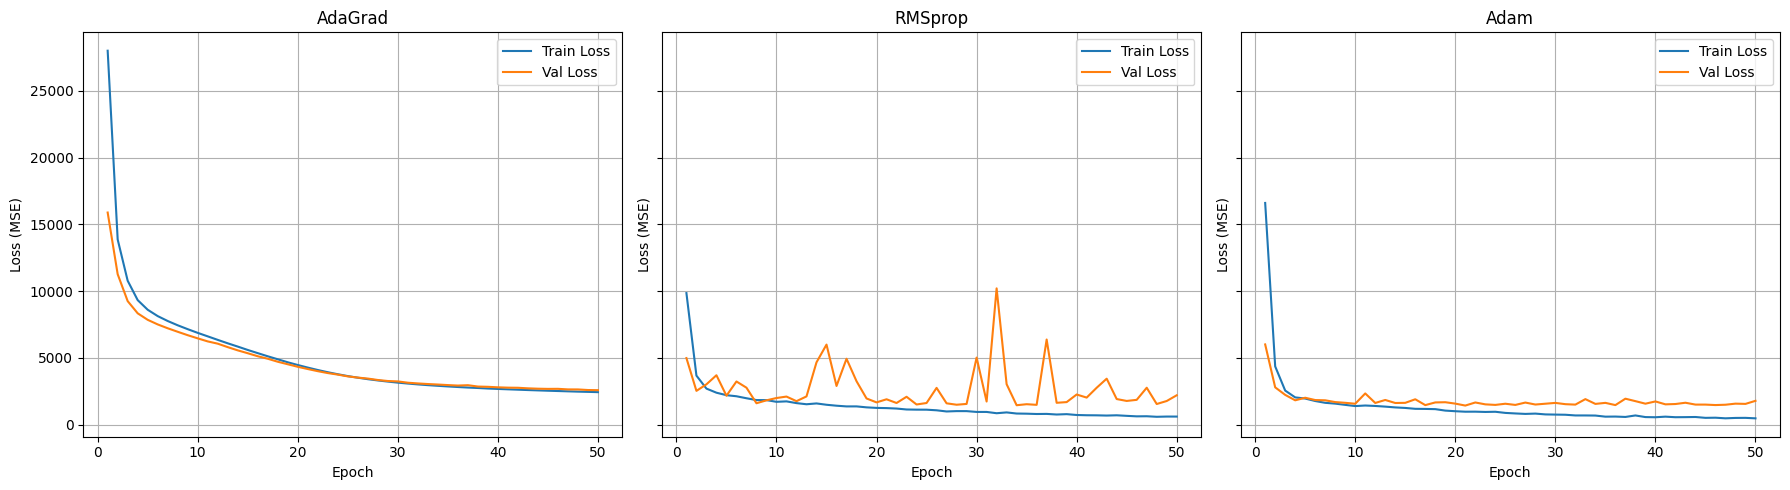

In [ ]:
### YOUR CODE STARTS HERE ###

epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# AdaGrad
axes[0].plot(epochs_range, train_losses_adagrad, label='Train Loss')
axes[0].plot(epochs_range, val_losses_adagrad,   label='Val Loss')
axes[0].set_title('AdaGrad')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# RMSprop
axes[1].plot(epochs_range, train_losses_rmsprop, label='Train Loss')
axes[1].plot(epochs_range, val_losses_rmsprop,   label='Val Loss')
axes[1].set_title('RMSprop')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True)

# Adam
axes[2].plot(epochs_range, train_losses_adam, label='Train Loss')
axes[2].plot(epochs_range, val_losses_adam,   label='Val Loss')
axes[2].set_title('Adam')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (MSE)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

### 3.3 Optimizer Validation Performance Summary & Selection (Q9) [2 Marks]

Q9: Compare validation performance of all three optimizers and select the best one.

**Steps:**
1. Evaluate all three models (AdaGrad, RMSprop, Adam) on `val_loader` using `evaluate_regression_model()`.
2. Construct a `pd.DataFrame` with columns: `['Optimizer', 'Validation MSE', 'Validation RMSE', 'Validation R² Score', 'Final Val Loss']`.
3. Sort the DataFrame by Validation R² Score descending and display it.
4. Extract the best optimizer name:
   ```python
   best_optimizer_name = df_val_summary.iloc[0]['Optimizer']
   ```
5. Print the selected best optimizer.


In [ ]:
### YOUR CODE STARTS HERE ###

# Evaluate all three models on the validation set
mse_adagrad, rmse_adagrad, r2_adagrad, _, _ = evaluate_regression_model(model_adagrad, val_loader, device=device)
mse_rmsprop, rmse_rmsprop, r2_rmsprop, _, _ = evaluate_regression_model(model_rmsprop, val_loader, device=device)
mse_adam,    rmse_adam,    r2_adam,    _, _ = evaluate_regression_model(model_adam,    val_loader, device=device)

# Build summary DataFrame
df_val_summary = pd.DataFrame([
    {
        'Optimizer': 'AdaGrad',
        'Validation MSE': mse_adagrad,
        'Validation RMSE': rmse_adagrad,
        'Validation R² Score': r2_adagrad,
        'Final Val Loss': val_losses_adagrad[-1]
    },
    {
        'Optimizer': 'RMSprop',
        'Validation MSE': mse_rmsprop,
        'Validation RMSE': rmse_rmsprop,
        'Validation R² Score': r2_rmsprop,
        'Final Val Loss': val_losses_rmsprop[-1]
    },
    {
        'Optimizer': 'Adam',
        'Validation MSE': mse_adam,
        'Validation RMSE': rmse_adam,
        'Validation R² Score': r2_adam,
        'Final Val Loss': val_losses_adam[-1]
    }
])

# Sort by Validation R² Score (descending)
df_val_summary = df_val_summary.sort_values('Validation R² Score', ascending=False).reset_index(drop=True)
display(df_val_summary)

# Select the best optimizer
best_optimizer_name = df_val_summary.iloc[0]['Optimizer']
print(f'Best optimizer selected: {best_optimizer_name}')

### YOUR CODE ENDS HERE ###

,Optimizer,Validation MSE,Validation RMSE,Validation R² Score,Final Val Loss
0,Adam,1784.770996,42.246550,0.944868,1784.770961
1,RMSprop,2200.906250,46.913817,0.932013,2200.906266
2,AdaGrad,2582.990723,50.823132,0.920210,2582.990826


Best optimizer selected: Adam


## Task 4: Regularization Study (Overfitting Analysis) [6 Marks]


### 4.1 Regularization Comparison & Generalization Gap (Q10) [6 Marks]

Q10: Train a regularized model using the winning optimizer selected in Q9 using `best_optimizer_name` and compare with the unregularized version.

**Steps:**
0. Call `set_seed(42)` before instantiating the model, so the regularized run starts from the same initialization as the unregularized baseline.
1. Instantiate a regularized model:
   ```python
   BikeRentalNN(input_dim=input_features, dropout_rate=0.25, use_dropout=True).to(device)
   ```
2. Store the two regularization settings as `dropout_rate = 0.25` and `l2_weight_decay = 1e-4` — **Q11 reuses both names**. Initialize the optimizer corresponding to `best_optimizer_name` with `weight_decay=l2_weight_decay`, `lr=0.001`.
3. Train the regularized model for `50 epochs` using `train_regression_model()`.
4. Plot a single comparative figure (`figsize=(11, 6.5)`) overlaying **4 curves** on the same axes:
   - Unregularized Train Loss
   - Unregularized Val Loss
   - Regularized Train Loss
   - Regularized Val Loss
5. Add title, axis labels, legend, and grid to visualize the generalization gap improvement.


Epoch [  1/50]  Train Loss: 17836.1906  Val Loss: 6233.9374
Epoch [ 10/50]  Train Loss: 3070.5799  Val Loss: 1985.2902
Epoch [ 20/50]  Train Loss: 2898.2802  Val Loss: 1810.8795
Epoch [ 30/50]  Train Loss: 2528.6473  Val Loss: 2114.7689
Epoch [ 40/50]  Train Loss: 2361.6098  Val Loss: 1493.8924
Epoch [ 50/50]  Train Loss: 2240.6758  Val Loss: 1434.5530


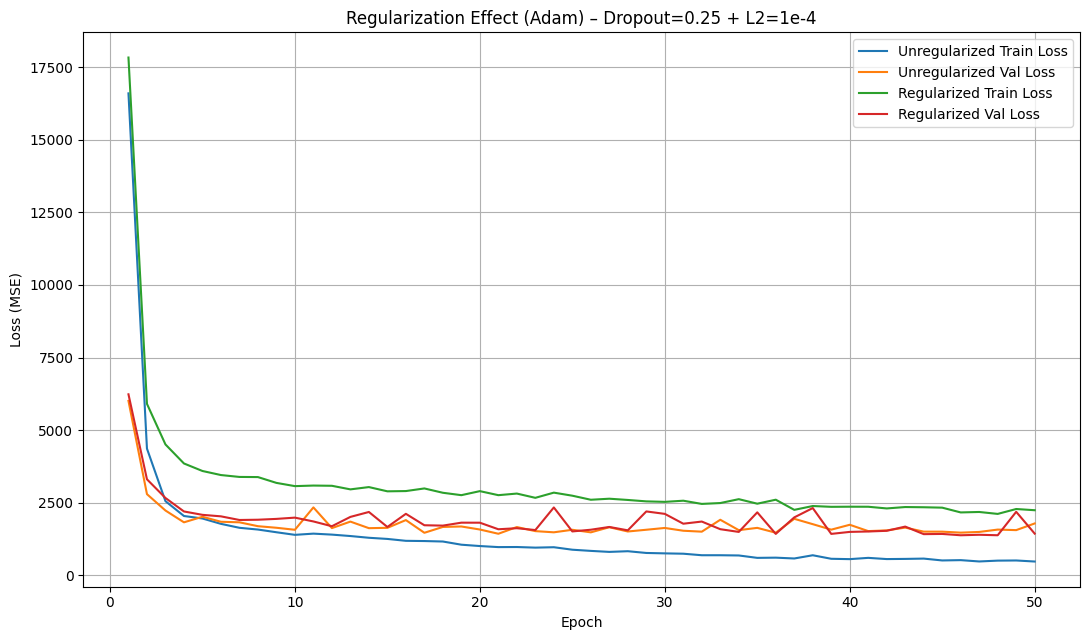

In [ ]:
### YOUR CODE STARTS HERE ###

# Regularization hyper-parameters (re-used by Q11)
dropout_rate = 0.25
l2_weight_decay = 1e-4

# ---------- Train regularized model ----------
set_seed(42)
model_regularized = BikeRentalNN(
    input_dim=input_features,
    dropout_rate=dropout_rate,
    use_dropout=True
).to(device)

# Create the same optimizer type that won in Q9, now with L2 weight decay
if best_optimizer_name == 'AdaGrad':
    optimizer_reg = optim.Adagrad(model_regularized.parameters(), lr=0.001, weight_decay=l2_weight_decay)
elif best_optimizer_name == 'RMSprop':
    optimizer_reg = optim.RMSprop(model_regularized.parameters(), lr=0.001, alpha=0.99, weight_decay=l2_weight_decay)
else:  # Adam
    optimizer_reg = optim.Adam(model_regularized.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=l2_weight_decay)

train_losses_reg, val_losses_reg = train_regression_model(
    model_regularized, optimizer_reg, criterion,
    train_loader, val_loader, epochs=50, device=device, print_interval=10
)

# ---------- Retrieve the corresponding unregularized histories ----------
if best_optimizer_name == 'AdaGrad':
    unreg_train, unreg_val = train_losses_adagrad, val_losses_adagrad
elif best_optimizer_name == 'RMSprop':
    unreg_train, unreg_val = train_losses_rmsprop, val_losses_rmsprop
else:
    unreg_train, unreg_val = train_losses_adam, val_losses_adam

# ---------- Comparative plot (4 curves) ----------
epochs_range = range(1, 51)
plt.figure(figsize=(11, 6.5))
plt.plot(epochs_range, unreg_train, label='Unregularized Train Loss')
plt.plot(epochs_range, unreg_val,   label='Unregularized Val Loss')
plt.plot(epochs_range, train_losses_reg, label='Regularized Train Loss')
plt.plot(epochs_range, val_losses_reg,   label='Regularized Val Loss')
plt.title(f'Regularization Effect ({best_optimizer_name}) – Dropout=0.25 + L2=1e-4')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

## Task 5: Test Set Evaluation & Prediction Visualizations [6 Marks]


### 5.1 Test Performance Metrics (Q11) [4 Marks]

Q11: Evaluate both model configurations (Unregularized vs Regularized with `best_optimizer_name`) on the unseen Test set.

**Steps:**
1. Evaluate the **Unregularized** model on `test_loader` using `evaluate_regression_model()`.
2. Evaluate the **Regularized** model on `test_loader` using `evaluate_regression_model()`.
3. Construct a `pd.DataFrame` with columns: `['Model', 'Regularization', 'Test MSE', 'Test RMSE', 'Test R² Score']`.
   - Row 1: `Unregularized {best_optimizer_name}` - Regularization = `None (Dropout=0, L2=0)`
   - Row 2: `Regularized {best_optimizer_name}` - Regularization = `Dropout=0.25, L2=0.0001` (formatted from your `dropout_rate` and `l2_weight_decay` variables)
4. Display the summary DataFrame.

> **Names Q12 reuses:** keep the predictions returned by `evaluate_regression_model()` as `preds_unreg` and `preds_reg`, and the returned ground-truth array as `targets_test`.


In [ ]:
### YOUR CODE STARTS HERE ###

# Identify the unregularized model that corresponds to the best optimizer
if best_optimizer_name == 'AdaGrad':
    model_unreg = model_adagrad
elif best_optimizer_name == 'RMSprop':
    model_unreg = model_rmsprop
else:
    model_unreg = model_adam

# Evaluate both models on the test set
mse_unreg, rmse_unreg, r2_unreg, preds_unreg, targets_test = evaluate_regression_model(
    model_unreg, test_loader, device=device
)
mse_reg, rmse_reg, r2_reg, preds_reg, _ = evaluate_regression_model(
    model_regularized, test_loader, device=device
)

# Build summary DataFrame
df_test_summary = pd.DataFrame([
    {
        'Model': f'Unregularized {best_optimizer_name}',
        'Regularization': 'None (Dropout=0, L2=0)',
        'Test MSE': mse_unreg,
        'Test RMSE': rmse_unreg,
        'Test R² Score': r2_unreg
    },
    {
        'Model': f'Regularized {best_optimizer_name}',
        'Regularization': f'Dropout={dropout_rate}, L2={l2_weight_decay}',
        'Test MSE': mse_reg,
        'Test RMSE': rmse_reg,
        'Test R² Score': r2_reg
    }
])

display(df_test_summary)

### YOUR CODE ENDS HERE ###

,Model,Regularization,Test MSE,Test RMSE,Test R² Score
0,Unregularized Adam,"None (Dropout=0, L2=0)",2087.688965,45.691235,0.932227
1,Regularized Adam,"Dropout=0.25, L2=0.0001",1670.825439,40.875732,0.945760


### 5.2 Prediction Visualizations & Scatter Plot (Q12) [2 Marks]

Q12: Create a scatter plot of True vs Predicted bike rental counts on the test set for the best model.

> **Model Selection Protocol:** The winning model is selected based on **Validation R² performance** (comparing the regularized model against the unregularized model on `val_loader`), and then visualized on the test set.

**Steps:**
1. Determine the best model configuration based on validation R² score.
2. Compute absolute prediction errors on the test set: `abs_errors = np.abs(targets_test - best_preds)`.
3. Create a scatter plot (`plt.figure(figsize=(9, 7))`) with:
   - x-axis: `targets_test` (Actual Bike Demand)
   - y-axis: `best_preds` (Predicted Bike Demand)
   - Color points by `abs_errors` using `cmap='viridis'` and `alpha=0.6`
4. Draw the ideal reference line `y = x` as a red dashed line (`'r--'`) from 0 to `max_val = max(targets_test.max(), best_preds.max())`.
5. Add a colorbar for the error magnitude.
6. Label axes: `'Actual Bike Demand (cnt)'` (x-axis), `'Predicted Bike Demand (cnt)'` (y-axis).
7. Add title with the model name and Test R² score annotated, and enable grid lines.


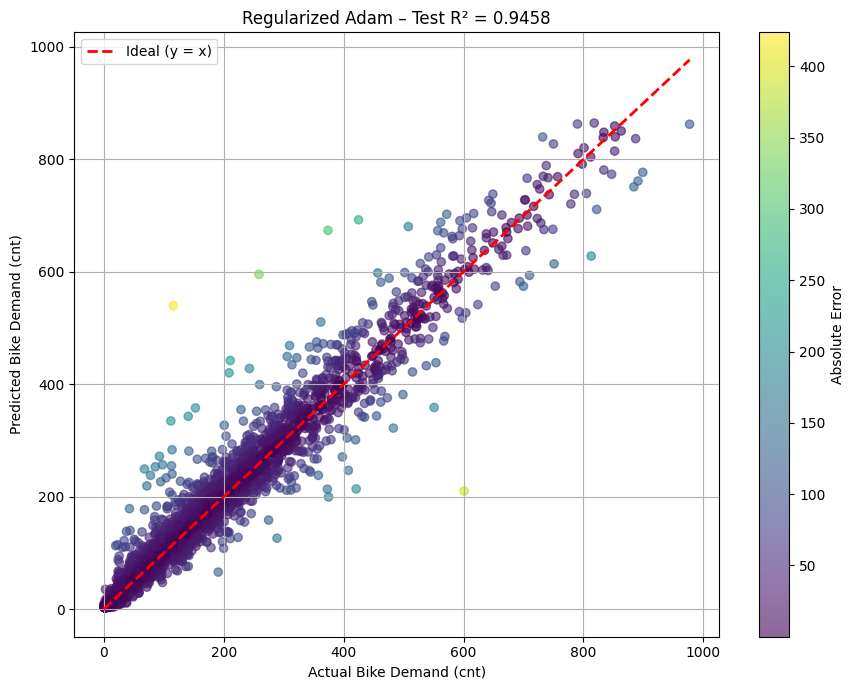

In [ ]:
### YOUR CODE STARTS HERE ###

# ---------- 1. Select best model based on Validation R² ----------
# Evaluate both models on the validation set
_, _, r2_val_unreg, _, _ = evaluate_regression_model(model_unreg, val_loader, device=device)
_, _, r2_val_reg,   _, _ = evaluate_regression_model(model_regularized, val_loader, device=device)

if r2_val_reg >= r2_val_unreg:
    best_preds = preds_reg
    best_model_name = f'Regularized {best_optimizer_name}'
    best_test_r2 = r2_reg
else:
    best_preds = preds_unreg
    best_model_name = f'Unregularized {best_optimizer_name}'
    best_test_r2 = r2_unreg

# ---------- 2. Absolute errors ----------
abs_errors = np.abs(targets_test - best_preds)

# ---------- 3-7. Scatter plot ----------
plt.figure(figsize=(9, 7))
sc = plt.scatter(targets_test, best_preds, c=abs_errors, cmap='viridis', alpha=0.6)
max_val = max(targets_test.max(), best_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideal (y = x)')
plt.colorbar(sc, label='Absolute Error')
plt.xlabel('Actual Bike Demand (cnt)')
plt.ylabel('Predicted Bike Demand (cnt)')
plt.title(f'{best_model_name} – Test R² = {best_test_r2:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

# Part 2: Video Action Recognition - Recurrent Models and CNN Fine-Tuning [60 Marks]

**Dataset:** [KTH Action Recognition Dataset](https://www.kaggle.com/datasets/vafaeii/kth-action-recognition-dataset)

In this part, you will build a video action classifier using deep convolutional features (ResNet-18) and recurrent models (RNN and LSTM). You will train recurrent heads on cached features, followed by fine-tuning the CNN backbone end-to-end.

> **GPU required.** Before running Part 2, switch the Colab runtime to a GPU: **Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU**. Stage-2 fine-tuning back-propagates through the CNN and is not feasible on CPU. Task 6 alone takes roughly 1.5-2 hours of GPU time, so run Part 2 in a single uninterrupted session.


---
## Task 0 - Imports and Setup [Provided / 0 Marks]

The following setup cells install dependencies, import libraries, configure directory paths, and set global hyperparameters for the video pipeline.


In [ ]:
import os
import sys

!{sys.executable} -m pip install -q opencv-python kagglehub numpy pandas matplotlib Pillow scikit-learn torch torchvision


In [ ]:
import gc
import json
import random
import re
import time
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from sklearn.metrics import precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms


## Global configuration


In [ ]:
SEED = 42

CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
NUM_CLASSES = len(CLASSES)

# Subject-wise split (no subject appears in more than one split).
TRAIN_SUBJECTS = set(range(1, 17))    # 1-16
VAL_SUBJECTS   = set(range(17, 21))   # 17-20
TEST_SUBJECTS  = set(range(21, 26))   # 21-25

# Clip sampling
CLIP_LEN   = 16       # Temporal samples per video
# Increment whenever frame extraction/sampling logic or cache format changes.
# This invalidates previously generated cached frames.
SAMPLING_VERSION = 2
IMAGE_SIZE = 224      # frames are cached already resized to 224x224

# Recurrent head
HIDDEN_SIZE = 64  # Hidden dimension for RNN/LSTM
NUM_LAYERS  = 1
DROPOUT     = 0.3
FEATURE_DIM = 512   # ResNet-18 global-average-pooled output

# Optimisation (shared by both stages)
OPTIMIZER_NAME          = "Adam"
WEIGHT_DECAY            = 1e-4
GRADIENT_CLIP_NORM      = 1.0
EARLY_STOPPING_PATIENCE = 5

# Stage 1 - trains on precomputed features, so batches can be large.
STAGE1_BATCH_SIZE = 32
STAGE1_MAX_EPOCHS = 50
STAGE1_LR         = 1e-3

# Stage 2 - backpropagates through the CNN, so the GPU batch is kept safe.
STAGE2_BATCH_SIZE        = 4
STAGE2_GRAD_ACCUMULATION = 4    # effective batch = 4 x 4 = 16
STAGE2_MAX_EPOCHS        = 50
STAGE2_LR                = 1e-4

# Paths
PROJECT_DIR  = Path.cwd()
DATASET_DIR  = PROJECT_DIR / "dataset"
CACHE_DIR    = DATASET_DIR / "cached_frames"
FEATURE_DIR  = DATASET_DIR / "features"
MODEL_DIR    = PROJECT_DIR / "models"

for directory in (DATASET_DIR, CACHE_DIR, FEATURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # Safe for cross-platform Jupyter execution


def set_seed(seed=SEED):
    """
    Sets random seeds across Python, NumPy, and PyTorch (CPU & CUDA)
    for reproducible results under a fixed environment.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

print(f"Device       : {DEVICE}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Classes      : {NUM_CLASSES} -> {CLASSES}")
print(f"Clip length  : {CLIP_LEN} frames @ {IMAGE_SIZE}x{IMAGE_SIZE}")


Device       : cuda
Workers      : 0
Classes      : 6 -> ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']
Clip length  : 16 frames @ 224x224


## Task 1 - Dataset Download [Provided / 0 Marks]

The following function downloads and verifies the raw video files for all 6 action classes.


In [ ]:
DATASET_PATH = None

# KaggleHub
if DATASET_PATH is None or not list(DATASET_PATH.rglob("*.avi")):
    try:
        import kagglehub
        path = Path(kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset"))
        if list(path.rglob("*.avi")):
            DATASET_PATH = path
            print("Successfully loaded dataset from KaggleHub!")
    except Exception as e:
        print(f"KaggleHub download notice: {e}")

# Fallback: Local raw directory
if DATASET_PATH is None or not list(DATASET_PATH.rglob("*.avi")):
    local_raw = Path("./dataset/raw")
    if local_raw.exists() and list(local_raw.rglob("*.avi")):
        DATASET_PATH = local_raw
        print(f"Using local raw dataset from: {DATASET_PATH}")
    else:
        raise RuntimeError("Could not locate KTH dataset files.")

VIDEO_FILES = sorted(DATASET_PATH.rglob("*.avi"))

print("Dataset path :", DATASET_PATH)
print("Videos found :", len(VIDEO_FILES))
print("Example      :", VIDEO_FILES[0].name)


100%|██████████| 1.07G/1.07G [00:31<00:00, 36.8MB/s]

Extracting files...


Successfully loaded dataset from KaggleHub!
Dataset path : /root/.cache/kagglehub/datasets/vafaeii/kth-action-recognition-dataset/versions/236
Videos found : 599
Example      : person01_boxing_d1_uncomp.avi


## Task 2 - Video Preprocessing Pipeline [Provided / 0 Marks]

The metadata extraction (Task 2.1) and frame decoding & caching (Task 2.2) are provided below.


### 2.1 - Metadata Parsing & Subject-Wise Split [Provided / 0 Marks]

The KTH dataset ships `00sequences.txt`, which splits each long take into multiple active sub-sequences. The cell below parses this manifest, pairs it with filename metadata, and assigns subject-wise splits (Train: 1-16, Val: 17-20, Test: 21-25).


In [ ]:
VIDEO_PATTERN = re.compile(r"person(\d+)_([A-Za-z]+)_(d\d)_uncomp\.avi$", re.IGNORECASE)

def parse_00sequences(filepath):
    """Parses 00sequences.txt into a dict mapping clean video stems to list of (start, end) tuples."""
    sequences = {}
    pattern = re.compile(r"^(person\d+_\w+_\w+)\s+frames\s+(.+)$")
    if not os.path.exists(filepath):
        return sequences

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            match = pattern.match(line)
            if match:
                stem, ranges_str = match.groups()
                ranges = []
                for r in ranges_str.split(","):
                    r = r.strip()
                    if "-" in r:
                        parts = r.split("-")
                        ranges.append((int(parts[0]), int(parts[1])))
                if ranges:
                    sequences[stem] = ranges
    return sequences


# Locate and parse 00sequences.txt
seq_file = DATASET_PATH / "00sequences.txt"
if not seq_file.exists():
    seq_files = list(DATASET_PATH.glob("**/00sequences.txt")) or list(Path(".").glob("**/00sequences.txt"))
    if seq_files:
        seq_file = seq_files[0]

SEQUENCE_RANGES = parse_00sequences(seq_file)
print(f"Loaded active sequence annotations for {len(SEQUENCE_RANGES)} video files from {seq_file.name}")


def assign_split(subject):
    if subject in TRAIN_SUBJECTS:
        return "train"
    if subject in VAL_SUBJECTS:
        return "val"
    if subject in TEST_SUBJECTS:
        return "test"
    raise ValueError(f"Subject {subject} is not in any split.")


def build_video_dataframe(video_files):
    records = []
    for video_path in video_files:
        match = VIDEO_PATTERN.search(video_path.name)
        if match is None:
            continue

        subject = int(match.group(1))
        action = match.group(2).lower()
        if action not in CLASSES:
            continue

        scenario = match.group(3).lower()
        clean_stem = f"person{subject:02d}_{action}_{scenario}"
        seq_ranges = SEQUENCE_RANGES.get(clean_stem, [])

        if seq_ranges:
            for seq_idx, (start_f, end_f) in enumerate(seq_ranges):
                records.append({
                    "path": video_path,
                    "stem": f"{clean_stem}_seq{seq_idx}",
                    "raw_stem": clean_stem,
                    "seq_idx": seq_idx,
                    "start_frame": start_f,
                    "end_frame": end_f,
                    "subject": subject,
                    "action": action,
                    "scenario": scenario,
                    "label": CLASSES.index(action),
                    "split": assign_split(subject),
                })
        else:
            records.append({
                "path": video_path,
                "stem": f"{clean_stem}_seq0",
                "raw_stem": clean_stem,
                "seq_idx": 0,
                "start_frame": 1,
                "end_frame": -1,
                "subject": subject,
                "action": action,
                "scenario": scenario,
                "label": CLASSES.index(action),
                "split": assign_split(subject),
            })

    dataframe = pd.DataFrame(records)
    if dataframe.empty:
        raise RuntimeError("No valid KTH videos could be parsed.")
    return dataframe


video_df = build_video_dataframe(VIDEO_FILES)

# Assert split isolation
assert not (TRAIN_SUBJECTS & VAL_SUBJECTS)
assert not (TRAIN_SUBJECTS & TEST_SUBJECTS)
assert not (VAL_SUBJECTS & TEST_SUBJECTS)
assert video_df["stem"].is_unique, "Clip cache folder names must be unique."

EXPECTED_CLIP_COUNT = 2391  # KTH active sub-sequences listed in 00sequences.txt

n_subjects = video_df["subject"].nunique()
print(f"Expanded dataset to {len(video_df)} clip samples across {n_subjects} subjects.\n")

if len(video_df) != EXPECTED_CLIP_COUNT:
    print(
        f"WARNING: built {len(video_df)} clips but expected {EXPECTED_CLIP_COUNT}.\n"
        f"         Active-sequence annotations parsed: {len(SEQUENCE_RANGES)}.\n"
        "         If that count is 0, 00sequences.txt was not found and each video\n"
        "         contributes a single uniform clip instead of its sub-sequences.\n"
        "         Split sizes and feature-tensor shapes will then differ from the\n"
        "         documented 1528 / 384 / 479.\n"
    )

print(video_df.groupby(["split", "action"]).size().unstack(fill_value=0))
print()
print(video_df["split"].value_counts().rename("clip_samples").to_frame())


Loaded active sequence annotations for 599 video files from 00sequences.txt
Expanded dataset to 2391 clip samples across 25 subjects.

action  boxing  handclapping  handwaving  jogging  running  walking
split                                                              
test        79            80          80       80       80       80
train      254           252         254      256      256      256
val         64            64          64       64       64       64

       clip_samples
split              
train          1528
test            479
val             384


### 2.2 - Frame Sampling and Disk Caching [Provided / 0 Marks]

The cells below decode video frames with OpenCV, sample `CLIP_LEN=16` uniformly spaced temporal positions per sequence (when the interval is shorter than 16 distinct integer positions, repeated source indices may occur after integer conversion; if an active sequence annotation is unavailable or invalid, the full decoded video is used as the sampling interval), resize them to 224x224 RGB, and cache them to disk.


In [ ]:
# --- 2.2 Active Multi-Sequence Frame Selection & Caching -------------------

def decode_video_frames(video_path):
    """Every decodable frame, BGR uint8. AVI frame-count metadata is not trusted."""
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise RuntimeError(f"Could not open video: {video_path}")

    frames = []
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        frames.append(frame)
    capture.release()

    if not frames:
        raise RuntimeError(f"No decodable frames in: {video_path}")
    return frames


def select_active_frame_indices(start_frame, end_frame, total_frames, clip_len=CLIP_LEN):
    """Uniformly samples `clip_len` temporal frame positions inside [start_frame, end_frame].
    If active sequence annotations are unavailable or invalid, falls back to uniform sampling
    over the entire decoded video."""
    if start_frame > 0 and end_frame > start_frame:
        start_idx = max(0, start_frame - 1)
        end_idx = min(total_frames - 1, end_frame - 1)
        if end_idx > start_idx:
            return np.linspace(start_idx, end_idx, clip_len, dtype=int), "00sequence_active"

    return np.linspace(0, total_frames - 1, clip_len, dtype=int), "uniform_clip"


def cache_video_frames(row):
    output_dir = CACHE_DIR / row.stem
    manifest_path = output_dir / "manifest.json"
    output_dir.mkdir(parents=True, exist_ok=True)

    if manifest_path.exists() and len(list(output_dir.glob("frame_*.jpg"))) == CLIP_LEN:
        manifest = json.loads(manifest_path.read_text())
        if manifest.get("version") == SAMPLING_VERSION:
            return manifest

    for stale in output_dir.glob("frame_*.jpg"):
        stale.unlink()

    frames = decode_video_frames(row.path)
    indices, strategy = select_active_frame_indices(row.start_frame, row.end_frame, len(frames))

    for position, source_index in enumerate(indices):
        source = frames[source_index]
        interpolation = cv2.INTER_AREA if source.shape[0] > IMAGE_SIZE else cv2.INTER_LINEAR
        resized = cv2.resize(source, (IMAGE_SIZE, IMAGE_SIZE), interpolation=interpolation)
        cv2.imwrite(str(output_dir / f"frame_{position:02d}.jpg"),
                    resized, [int(cv2.IMWRITE_JPEG_QUALITY), 92])

    manifest = {
        "version": SAMPLING_VERSION,
        "strategy": strategy,
        "indices": [int(i) for i in indices],
        "n_decoded": len(frames),
        "window": [int(indices[0]), int(indices[-1])],
    }
    manifest_path.write_text(json.dumps(manifest))
    return manifest


start_time = time.time()
manifests = {}
reused = 0

for counter, row in enumerate(video_df.itertuples(index=False), start=1):
    before = (CACHE_DIR / row.stem / "manifest.json").exists()
    manifests[row.stem] = cache_video_frames(row)
    if before and manifests[row.stem].get("version") == SAMPLING_VERSION:
        reused += 1

    if counter % 200 == 0 or counter == len(video_df):
        print(f"  {counter:>4}/{len(video_df)} clips processed")

print(f"\nDone frame extraction in {(time.time() - start_time) / 60:.2f} min ({reused}/{len(video_df)} clips reused from cache).")
video_df["strategy"] = video_df["stem"].map(lambda s: manifests[s]["strategy"])


   200/2391 clips processed
   400/2391 clips processed
   600/2391 clips processed
   800/2391 clips processed
  1000/2391 clips processed
  1200/2391 clips processed
  1400/2391 clips processed
  1600/2391 clips processed
  1800/2391 clips processed
  2000/2391 clips processed
  2200/2391 clips processed
  2391/2391 clips processed

Done frame extraction in 3.66 min (0/2391 clips reused from cache).


## Task 3: Video Dataset Implementation & Exploratory Analysis [9 Marks]


### 3.0 - PyTorch Dataset Implementation [Provided / 0 Marks]

The following cell defines `KTHClipDataset(Dataset)` which loads the 16 cached frame JPEGs for a video sequence, applies ImageNet normalization via `frame_transform`, and returns a clip tensor `(16, 3, 224, 224)` with an integer class label.


In [ ]:
frame_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class KTHClipDataset(Dataset):
    """Loads one cached clip: (CLIP_LEN, 3, IMAGE_SIZE, IMAGE_SIZE) float tensor + label."""

    def __init__(self, dataframe, transform=frame_transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        clip_dir = CACHE_DIR / row['stem']
        frames = []
        for i in range(CLIP_LEN):
            frame_path = clip_dir / f"frame_{i:02d}.jpg"
            img = Image.open(frame_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        clip_tensor = torch.stack(frames)
        label = torch.tensor(row['label'], dtype=torch.long)
        return clip_tensor, label


# Quick shape check
sample_ds = KTHClipDataset(video_df.head(1))
clip, label = sample_ds[0]
print(f"Sample clip tensor shape: {clip.shape}, dtype: {clip.dtype}")
print(f"Label: {label}")


Sample clip tensor shape: torch.Size([16, 3, 224, 224]), dtype: torch.float32
Label: 0


### 3.1 Dataset Splitting & DataLoaders (Q13) [4 Marks]

Q13: Split `video_df` by the `split` column, create `KTHClipDataset` instances, and build PyTorch `DataLoader` objects.

**Provided below:**
- Train split filtering and `train_dataset` creation
- `DATASETS` dictionary initialized with `train`
- `make_clip_loader()` helper function
- `train_clip_loader` created with `batch_size=STAGE1_BATCH_SIZE` (`shuffle=True`)

**Tasks to complete:**
1. Create `val_dataset` and `test_dataset` from `video_df` (filtering by `split == 'val'` and `split == 'test'`) and add them to the `DATASETS` dictionary (`'val': val_dataset`, `'test': test_dataset`).
2. Verify with assertions that `val` and `test` datasets are created and populated.
3. Build the remaining clip DataLoaders using `make_clip_loader`:
   - `val_clip_loader`, `test_clip_loader` (`batch_size=STAGE1_BATCH_SIZE`, `shuffle=False`)
4. Build the Stage-2 DataLoaders:
   - `stage2_train_loader` (`batch_size=STAGE2_BATCH_SIZE`, `shuffle=True`)
   - `stage2_val_loader`, `stage2_test_loader` (`batch_size=STAGE2_BATCH_SIZE`, `shuffle=False`)
5. Verify with assertions that all DataLoaders are defined.
6. Print the sample counts for each split.

**Expected:** Train: 1528, Val: 384, Test: 479 sequences (matching the feature tensor shapes in Q18).


In [ ]:
### YOUR CODE STARTS HERE ###

# Train Val Test split
split_frames = {}
split_frames['train'] = video_df[video_df['split'] == 'train'].reset_index(drop=True)
train_dataset = KTHClipDataset(split_frames['train'], frame_transform)

# Create val_dataset and test_dataset similarly for 'val' and 'test' splits
# and add them to the DATASETS map
split_frames['val']  = video_df[video_df['split'] == 'val'].reset_index(drop=True)
split_frames['test'] = video_df[video_df['split'] == 'test'].reset_index(drop=True)

val_dataset  = KTHClipDataset(split_frames['val'],  frame_transform)
test_dataset = KTHClipDataset(split_frames['test'], frame_transform)

DATASETS = {
    'train': train_dataset,
    'val':   val_dataset,
    'test':  test_dataset
}

# Assert that val and test datasets were created and added to DATASETS
assert 'val' in DATASETS and DATASETS['val'] is not None
assert 'test' in DATASETS and DATASETS['test'] is not None
assert len(DATASETS['val'])  > 0
assert len(DATASETS['test']) > 0


def make_clip_loader(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
                      drop_last=False)


train_clip_loader = make_clip_loader(train_dataset, batch_size=STAGE1_BATCH_SIZE, shuffle=True)

# Build val_clip_loader and test_clip_loader (batch_size=STAGE1_BATCH_SIZE, shuffle=False)
val_clip_loader  = make_clip_loader(val_dataset,  batch_size=STAGE1_BATCH_SIZE, shuffle=False)
test_clip_loader = make_clip_loader(test_dataset, batch_size=STAGE1_BATCH_SIZE, shuffle=False)

# Build stage2_train_loader (batch_size=STAGE2_BATCH_SIZE, shuffle=True)
stage2_train_loader = make_clip_loader(train_dataset, batch_size=STAGE2_BATCH_SIZE, shuffle=True)

# Build stage2_val_loader and stage2_test_loader (batch_size=STAGE2_BATCH_SIZE, shuffle=False)
stage2_val_loader  = make_clip_loader(val_dataset,  batch_size=STAGE2_BATCH_SIZE, shuffle=False)
stage2_test_loader = make_clip_loader(test_dataset, batch_size=STAGE2_BATCH_SIZE, shuffle=False)

# Assertions and print summary
assert all(x is not None for x in [
    val_clip_loader, test_clip_loader,
    stage2_train_loader, stage2_val_loader, stage2_test_loader
])

print({k: len(v) for k, v in split_frames.items()})
# Expected: {'train': 1528, 'val': 384, 'test': 479}

### YOUR CODE ENDS HERE ###

{'train': 1528, 'val': 384, 'test': 479}


### 3.2 Sample Video Clip Visualization (Q14) [2 Marks]

Q14: Generate a visual grid showing temporal frames for 1 sample clip from each of the 6 action classes.

**Steps:**
1. For each of the 6 action classes (`boxing`, `handclapping`, `handwaving`, `jogging`, `running`, `walking`), pick the first matching row in `video_df`.
2. Sample 8 evenly spaced frame indices from the 16 cached frames: `frame_positions = np.linspace(0, len(all_frame_files) - 1, COLUMNS, dtype=int)`.
3. Create a `6×8` subplot grid.
4. For each row, load and display the 8 sampled frames using `Image.open(...)`.
5. Label each row with the action name and sampling strategy. Label each column with timestep `t={pos}`.


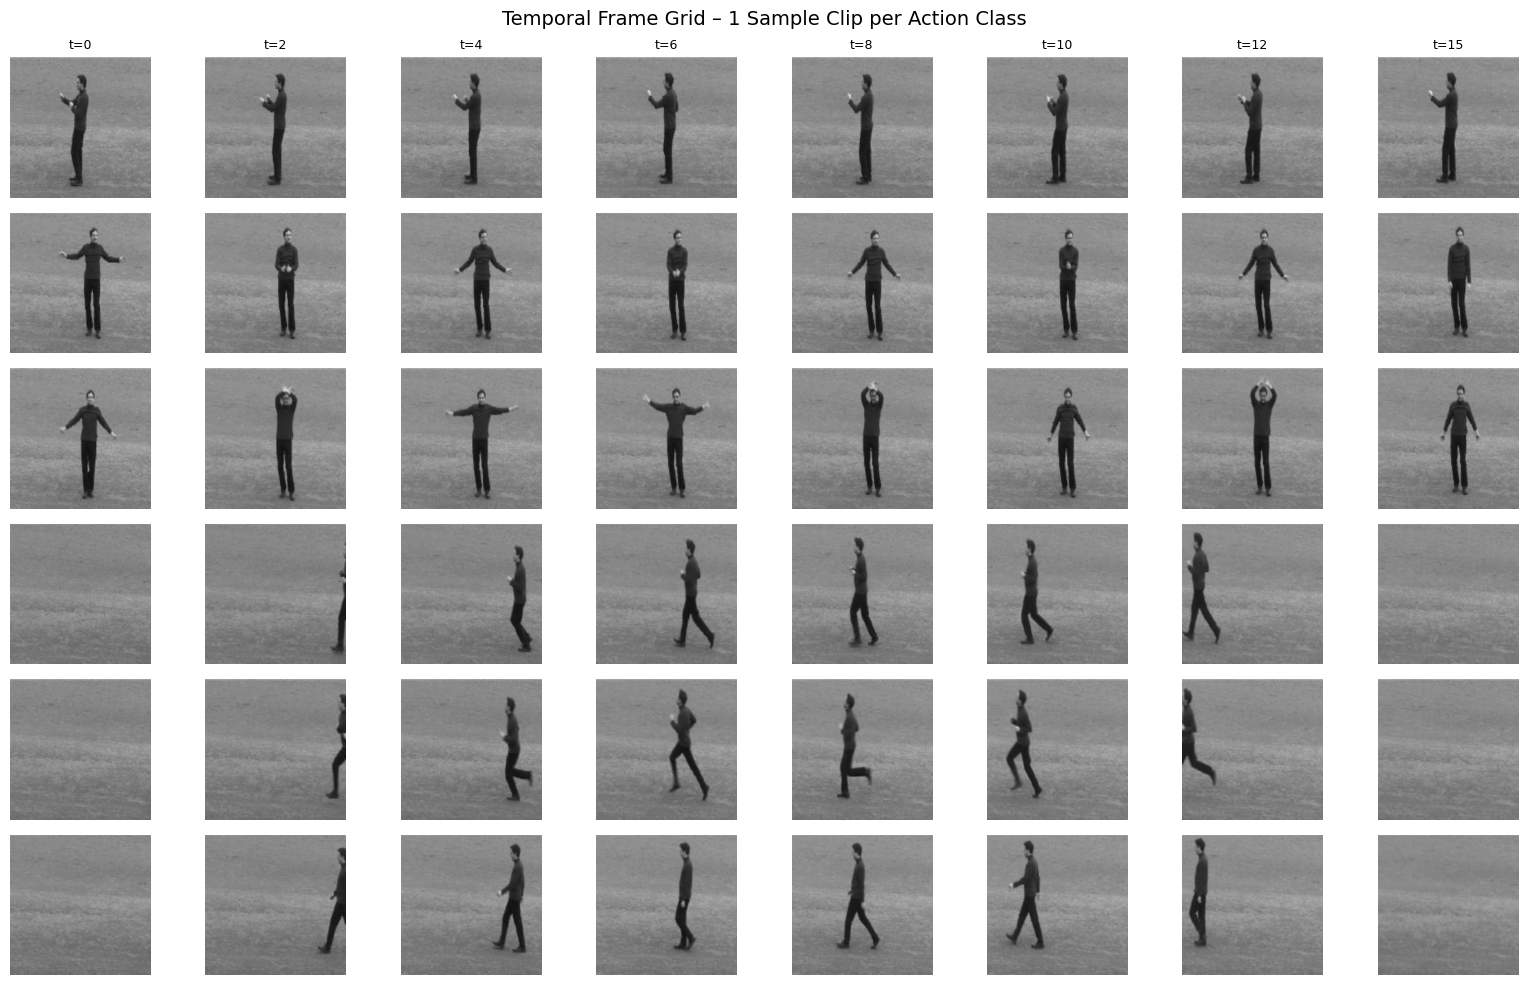

In [ ]:
### YOUR CODE STARTS HERE ###

COLUMNS = 8
fig, axes = plt.subplots(NUM_CLASSES, COLUMNS, figsize=(16, 10))

for row_idx, action in enumerate(CLASSES):
    # Pick the first matching row for this action
    row = video_df[video_df['action'] == action].iloc[0]
    clip_dir = CACHE_DIR / row['stem']
    all_frame_files = sorted(clip_dir.glob('frame_*.jpg'))

    # Sample 8 evenly spaced frame indices
    frame_positions = np.linspace(0, len(all_frame_files) - 1, COLUMNS, dtype=int)

    for col_idx, pos in enumerate(frame_positions):
        ax = axes[row_idx, col_idx]
        img = Image.open(all_frame_files[pos])
        ax.imshow(img)
        ax.axis('off')

        if row_idx == 0:
            ax.set_title(f't={pos}', fontsize=9)
        if col_idx == 0:
            strategy = row.get('strategy', 'unknown')
            ax.set_ylabel(f'{action}\n({strategy})', fontsize=9, rotation=0,
                          labelpad=40, va='center')

plt.suptitle('Temporal Frame Grid – 1 Sample Clip per Action Class', fontsize=14)
plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

### 3.3 Action Class Distribution Analysis (Q15) [3 Marks]

Q15: Analyze and plot the action class distribution across Train/Val/Test splits.

**Steps:**
1. Aggregate sequence counts:
   ```python
   counts = video_df.groupby(['split', 'action']).size().unstack(fill_value=0)
                    .reindex(index=['train', 'val', 'test'], columns=CLASSES)
   ```
2. Plot a **grouped bar chart** showing sequence clips per action class, grouped by split.
3. Plot a **bar chart** of total sequence clips per split with exact count annotations on each bar.
4. Display the underlying counts table using `display()`.


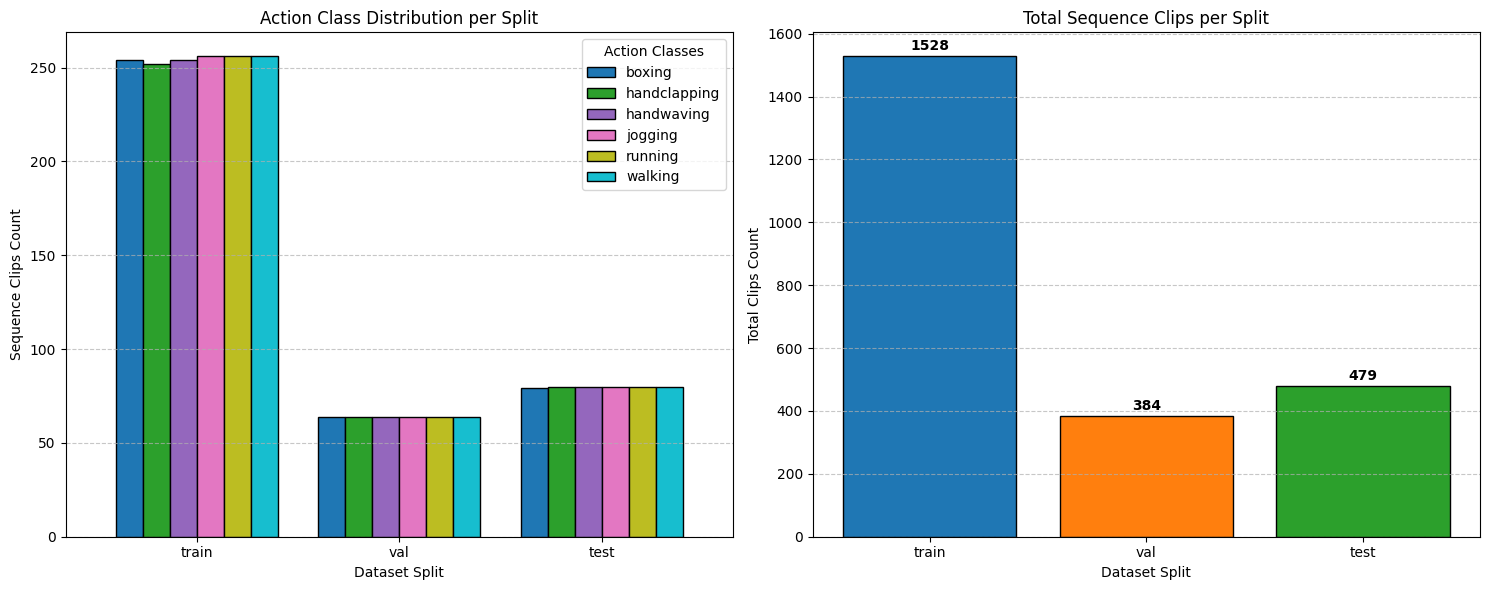

action,boxing,handclapping,handwaving,jogging,running,walking
split,,,,,,
train,254,252,254,256,256,256
val,64,64,64,64,64,64
test,79,80,80,80,80,80


In [ ]:
### YOUR CODE STARTS HERE ###

# 1. Aggregate sequence counts
counts = video_df.groupby(['split', 'action']).size().unstack(fill_value=0).reindex(index=['train', 'val', 'test'], columns=CLASSES)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot a grouped bar chart showing sequence clips per action class, grouped by split
counts.plot(kind='bar', ax=axes[0], width=0.8, colormap='tab10', edgecolor='black')
axes[0].set_title('Action Class Distribution per Split')
axes[0].set_xlabel('Dataset Split')
axes[0].set_ylabel('Sequence Clips Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Action Classes')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Plot a bar chart of total sequence clips per split with exact count annotations
split_totals = counts.sum(axis=1)
bars = axes[1].bar(split_totals.index, split_totals.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[1].set_title('Total Sequence Clips per Split')
axes[1].set_xlabel('Dataset Split')
axes[1].set_ylabel('Total Clips Count')

# Annotate exact counts on each bar
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 10,
                 str(int(height)), ha='center', va='bottom', fontweight='bold')

axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Display the underlying counts table
display(counts)

### YOUR CODE ENDS HERE ###

## Task 4: Spatial Feature Extractor & Recurrent Models [14 Marks]


### 4.1 Frozen Spatial Feature Extractor - `FrozenResNet18` (Q16) [4 Marks]

Q16: Define a permanently frozen ResNet-18 feature extractor. Maps `(B, 16, 3, 224, 224)` → `(B, 16, 512)`.

- `__init__()`: Load `models.resnet18(weights=ResNet18_Weights.DEFAULT)`, replace `fc` with `nn.Identity()`, freeze all parameters (`p.requires_grad = False`), and call `self.eval()` so all submodules (including BatchNorm) enter evaluation mode.
- `train(mode=True)`: Override to ensure the extractor always remains in eval mode (`return super().train(False)`).
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → `backbone` → reshape to `(B, T, 512)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class FrozenResNet18(nn.Module):
    """
    ImageNet-pretrained ResNet-18 without its linear head; all parameters frozen.
    Maps (B, 16, 3, 224, 224) -> (B, 16, 512).
    """
    def __init__(self):
        super().__init__()
        # 1. Load models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # 2. Replace backbone.fc with nn.Identity()
        self.backbone.fc = nn.Identity()

        # 3. Freeze every backbone parameter (requires_grad = False)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 4. Call self.eval() so all submodules (including BatchNorm) start in eval mode
        self.eval()

    def train(self, mode=True):
        # Override so the module always stays in eval mode: return super().train(False)
        return super().train(False)

    def forward(self, clips):
        # Flatten (B, T, C, H, W) -> (B*T, C, H, W), run through self.backbone,
        # reshape the result back to (B, T, FEATURE_DIM)
        B, T, C, H, W = clips.shape
        x = clips.view(B * T, C, H, W)
        features = self.backbone(x)
        return features.view(B, T, FEATURE_DIM)

# Verify the output shape and that no parameters are trainable, on a dummy
# (2, CLIP_LEN, 3, IMAGE_SIZE, IMAGE_SIZE) input.
dummy_input = torch.randn(2, CLIP_LEN, 3, IMAGE_SIZE, IMAGE_SIZE)
dummy_model = FrozenResNet18()
dummy_output = dummy_model(dummy_input)

trainable_params = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)

print(f"Dummy input shape: {dummy_input.shape}")
print(f"Model output shape: {dummy_output.shape}")
print(f"Trainable parameters: {trainable_params}")

# Optional assertions to strictly confirm
assert dummy_output.shape == (2, CLIP_LEN, FEATURE_DIM), f"Unexpected output shape: {dummy_output.shape}"
assert trainable_params == 0, f"Expected 0 trainable parameters, found {trainable_params}"

### YOUR CODE ENDS HERE ###

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Dummy input shape: torch.Size([2, 16, 3, 224, 224])
Model output shape: torch.Size([2, 16, 512])
Trainable parameters: 0


### 4.2 Recurrent Head Architecture `RecurrentHead` (Q17) [10 Marks]

Q17: Design a modular `RecurrentHead(nn.Module)` supporting RNN and LSTM with configurable directionality.

**Constructor arguments:** `(recurrent_type, bidirectional, input_size=512, hidden_size=64, num_layers=1, num_classes=6, dropout=0.3)`
- `recurrent_type`: `'rnn'` or `'lstm'` (`nn.RNN` or `nn.LSTM` with `batch_first=True`, `bidirectional=bidirectional`)
- Temporal pooling uses the last timestep. For unidirectional, take `outputs[:, -1, :]`. For bidirectional, concatenate the forward last timestep (`outputs[:, -1, :hidden_size]`) with the backward last timestep (`outputs[:, 0, hidden_size:]`).
- `dropout`: `nn.Dropout(dropout)` applied before the linear classifier.
- `classifier`: `nn.Linear(classifier_input_dim, num_classes)`.
  - `classifier_input_dim = hidden_size * (2 if bidirectional else 1)`

**Forward pass:** `features` `(B, 16, 512)` -> recurrent layer -> pool temporal dimension -> dropout -> classifier -> return raw logits `(B, 6)`.

**Helper functions provided:**
- `count_parameters(model)`: Returns `(total_params, trainable_params)`.
- `get_submodule_parameter_breakdown(model)`: Returns per-submodule parameter breakdown table.

**Task:** Instantiate the 4 core configurations and display their parameter summaries. `STAGE1_CORE_CONFIGS` is provided in the code cell below; Q21 and Q23 index it by these exact keys, so do not rename them.

| Config key | `recurrent_type` | `bidirectional` |
|---|---|---|
| `rnn_uni` | `'rnn'` | `False` |
| `rnn_bi` | `'rnn'` | `True` |
| `lstm_uni` | `'lstm'` | `False` |
| `lstm_bi` | `'lstm'` | `True` |


In [ ]:
### YOUR CODE STARTS HERE ###

class RecurrentHead(nn.Module):
    def __init__(self, recurrent_type, bidirectional,
                 input_size=FEATURE_DIM, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
                 dropout=DROPOUT):
        super().__init__()
        # 1. Validate recurrent_type ('rnn' or 'lstm')
        self.recurrent_type = recurrent_type.lower()
        if self.recurrent_type not in ['rnn', 'lstm']:
            raise ValueError("recurrent_type must be either 'rnn' or 'lstm'")

        self.bidirectional = bidirectional
        self.hidden_size = hidden_size

        # 2. Instantiate self.recurrent (nn.RNN or nn.LSTM with batch_first=True)
        if self.recurrent_type == 'rnn':
            self.recurrent = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                                    num_layers=num_layers, batch_first=True,
                                    bidirectional=bidirectional)
        else:
            self.recurrent = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                     num_layers=num_layers, batch_first=True,
                                     bidirectional=bidirectional)

        # 3. output_dim = hidden_size * (2 if bidirectional else 1)
        output_dim = hidden_size * (2 if bidirectional else 1)

        # 4. self.dropout = nn.Dropout(dropout)
        self.dropout = nn.Dropout(dropout)

        # 5. self.classifier = nn.Linear(output_dim, num_classes)
        self.classifier = nn.Linear(output_dim, num_classes)

    def forward(self, features):
        # 1. Run features through self.recurrent: outputs, _ = self.recurrent(features)
        outputs, _ = self.recurrent(features)

        # 2. Pool the temporal dimension using the last timestep
        if self.bidirectional:
            # cat forward last & backward first
            forward_last = outputs[:, -1, :self.hidden_size]
            backward_last = outputs[:, 0, self.hidden_size:]
            pooled = torch.cat((forward_last, backward_last), dim=-1)
        else:
            # take the last timestep
            pooled = outputs[:, -1, :]

        # 3. Apply dropout and linear classifier, return logits
        out = self.dropout(pooled)
        logits = self.classifier(out)
        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def get_submodule_parameter_breakdown(model, model_name=""):
    rows = []
    for name, module in model.named_children():
        n_params = sum(p.numel() for p in module.parameters())
        n_train = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append({
            "Submodule": name,
            "Type": module.__class__.__name__,
            "Total Parameters": f"{n_params:,}",
            "Trainable": f"{n_train:,}",
            "Frozen": f"{n_params - n_train:,}",
        })
    total, trainable = count_parameters(model)
    rows.append({
        "Submodule": "Total",
        "Type": model.__class__.__name__,
        "Total Parameters": f"{total:,}",
        "Trainable": f"{trainable:,}",
        "Frozen": f"{total - trainable:,}",
    })
    return pd.DataFrame(rows)


STAGE1_CORE_CONFIGS = {
    "rnn_uni":  {"recurrent_type": "rnn",  "bidirectional": False},
    "rnn_bi":   {"recurrent_type": "rnn",  "bidirectional": True},
    "lstm_uni": {"recurrent_type": "lstm", "bidirectional": False},
    "lstm_bi":  {"recurrent_type": "lstm", "bidirectional": True},
}

# Instantiate each head and display a parameter breakdown table for all 4 models.
for config_key, config_params in STAGE1_CORE_CONFIGS.items():
    print(f"--- Model Configuration: {config_key} ---")
    model = RecurrentHead(**config_params)
    breakdown_df = get_submodule_parameter_breakdown(model, config_key)
    display(breakdown_df)
    print("\n")

### YOUR CODE ENDS HERE ###

--- Model Configuration: rnn_uni ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,recurrent,RNN,"36,992","36,992",0
1,dropout,Dropout,0,0,0
2,classifier,Linear,390,390,0
3,Total,RecurrentHead,"37,382","37,382",0




--- Model Configuration: rnn_bi ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,recurrent,RNN,"73,984","73,984",0
1,dropout,Dropout,0,0,0
2,classifier,Linear,774,774,0
3,Total,RecurrentHead,"74,758","74,758",0




--- Model Configuration: lstm_uni ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,recurrent,LSTM,"147,968","147,968",0
1,dropout,Dropout,0,0,0
2,classifier,Linear,390,390,0
3,Total,RecurrentHead,"148,358","148,358",0




--- Model Configuration: lstm_bi ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,recurrent,LSTM,"295,936","295,936",0
1,dropout,Dropout,0,0,0
2,classifier,Linear,774,774,0
3,Total,RecurrentHead,"296,710","296,710",0


## Task 5: Stage-1 Recurrent Model Training & Evaluation [17 Marks]


### 5.1 Extracting and Saving Features to Disk (Q18) [2 Marks]

Q18: Precompute spatial features using `FrozenResNet18` and save them to disk for fast Stage-1 training.

**Provided below:**
- Full implementation of `extract_features(dataset, backbone, batch_size=16, desc=...)`
- `FrozenResNet18` extractor instantiation
- Complete feature extraction, disk saving (`torch.save((train_features, train_labels), FEATURE_DIR / "train_features.pt")`), and `stage1_train_loader` setup for the **train** split

**Tasks to complete:**
1. Extract and save features for **validation** (`val_features.pt`) and **test** (`test_features.pt`) splits to `FEATURE_DIR`.
2. Free the extractor from memory: `del extractor` + `gc.collect()` + `torch.cuda.empty_cache()`.
3. Construct `stage1_val_loader` and `stage1_test_loader` over `TensorDataset(features, labels)` with `batch_size=STAGE1_BATCH_SIZE` (`shuffle=False`, `num_workers=NUM_WORKERS`, `pin_memory=(DEVICE.type == "cuda")`).
4. Verify with the provided assertions that files are saved and DataLoaders are created.

**Expected tensor shapes:** Train `(1528, 16, 512)`, Val `(384, 16, 512)`, Test `(479, 16, 512)`.


In [ ]:
### YOUR CODE STARTS HERE ###

@torch.no_grad()
def extract_features(dataset, backbone, batch_size=16, desc="Extracting features"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
    feature_batches, label_batches = [], []
    total_batches = len(loader)

    for i, (clips, labels) in enumerate(loader, 1):
        clips = clips.to(DEVICE, non_blocking=True)
        features = backbone(clips)
        feature_batches.append(features.cpu())
        label_batches.append(labels.clone())
        if i % 15 == 0 or i == total_batches:
            print(f"  [{desc}] Batch [{i:02d}/{total_batches:02d}] extracted")

    return (torch.cat(feature_batches, dim=0),
            torch.cat(label_batches, dim=0))


extractor = FrozenResNet18().to(DEVICE)

print("Starting spatial feature precomputation with FrozenResNet18...")

# --- Provided: Train split feature extraction, disk saving, and DataLoader ---
train_features, train_labels = extract_features(train_dataset, extractor, desc="Train Features")
torch.save((train_features, train_labels), FEATURE_DIR / "train_features.pt")
print(f"  train: {train_features.shape}, labels: {train_labels.shape}")

stage1_train_loader = DataLoader(
    TensorDataset(train_features, train_labels),
    batch_size=STAGE1_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

# 1. Extract and save val_features, val_labels to FEATURE_DIR / "val_features.pt"
val_features, val_labels = extract_features(val_dataset, extractor, desc="Val Features")
torch.save((val_features, val_labels), FEATURE_DIR / "val_features.pt")

# 2. Extract and save test_features, test_labels to FEATURE_DIR / "test_features.pt"
test_features, test_labels = extract_features(test_dataset, extractor, desc="Test Features")
torch.save((test_features, test_labels), FEATURE_DIR / "test_features.pt")

# 3. Free extractor memory (del extractor, gc.collect(), torch.cuda.empty_cache() if GPU available)
del extractor
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 4. Construct stage1_val_loader and stage1_test_loader (batch_size=STAGE1_BATCH_SIZE, shuffle=False)
stage1_val_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=STAGE1_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

stage1_test_loader = DataLoader(
    TensorDataset(test_features, test_labels),
    batch_size=STAGE1_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

# Assertions
assert 'val_features' in locals() and 'val_labels' in locals(), "val_features and val_labels must be defined."
assert 'test_features' in locals() and 'test_labels' in locals(), "test_features and test_labels must be defined."
assert (FEATURE_DIR / "val_features.pt").exists() and (FEATURE_DIR / "test_features.pt").exists(), "val_features.pt and test_features.pt must be saved to disk."
assert 'stage1_val_loader' in locals() and 'stage1_test_loader' in locals(), "stage1_val_loader and stage1_test_loader must be defined."
assert len(stage1_val_loader) > 0 and len(stage1_test_loader) > 0, "DataLoaders must not be empty."

print(f"Features saved to {FEATURE_DIR}:")
print(f"  train: {train_features.shape}, labels: {train_labels.shape}")
print(f"  val:   {val_features.shape}, labels: {val_labels.shape}")
print(f"  test:  {test_features.shape}, labels: {test_labels.shape}")

### YOUR CODE ENDS HERE ###

Starting spatial feature precomputation with FrozenResNet18...
  [Train Features] Batch [15/96] extracted
  [Train Features] Batch [30/96] extracted
  [Train Features] Batch [45/96] extracted
  [Train Features] Batch [60/96] extracted
  [Train Features] Batch [75/96] extracted
  [Train Features] Batch [90/96] extracted
  [Train Features] Batch [96/96] extracted
  train: torch.Size([1528, 16, 512]), labels: torch.Size([1528])
  [Val Features] Batch [15/24] extracted
  [Val Features] Batch [24/24] extracted
  [Test Features] Batch [15/30] extracted
  [Test Features] Batch [30/30] extracted
Features saved to /content/dataset/features:
  train: torch.Size([1528, 16, 512]), labels: torch.Size([1528])
  val:   torch.Size([384, 16, 512]), labels: torch.Size([384])
  test:  torch.Size([479, 16, 512]), labels: torch.Size([479])


### 5.2 Evaluation Function - `evaluate_classification_model` (Q19) [2 Marks]

Q19: Implement `evaluate_classification_model` - evaluates a model on a given DataLoader.

**Signature:** `evaluate_classification_model(model, data_loader, criterion=None)`

**Steps:**
1. Decorate with `@torch.no_grad()`, set `model.eval()`. If `criterion is None`, default to `nn.CrossEntropyLoss()`.
2. Loop through batches, compute average cross-entropy loss and accuracy.
3. Collect predictions and ground truth labels as numpy arrays.
4. Return `(loss, accuracy, predictions_numpy, ground_truth_numpy)`.


In [ ]:
### YOUR CODE STARTS HERE ###

@torch.no_grad()
def evaluate_classification_model(model, data_loader, criterion=None):
    # 1. If criterion is None, default to nn.CrossEntropyLoss()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    # 2. Set model.eval(), loop batches, compute total loss and accuracy
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Lists to collect predictions and ground truth
    preds_list = []
    targets_list = []

    for features, labels in data_loader:
        # Move inputs to the globally defined DEVICE
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels)

        # Accumulate loss (multiply by batch size to get total loss for the batch)
        total_loss += loss.item() * features.size(0)

        # Get predictions (highest logit)
        _, preds = torch.max(outputs, dim=1)

        # Accumulate accuracy metrics
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

        # 3. Collect predictions and ground truth as numpy arrays
        preds_list.append(preds.cpu().numpy())
        targets_list.append(labels.cpu().numpy())

    # Calculate average loss and accuracy
    avg_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    # Concatenate lists of arrays into single numpy arrays
    predictions_numpy = np.concatenate(preds_list)
    ground_truth_numpy = np.concatenate(targets_list)

    # 4. Return (loss, accuracy, predictions_numpy, ground_truth_numpy)
    return avg_loss, accuracy, predictions_numpy, ground_truth_numpy

### YOUR CODE ENDS HERE ###

### 5.3 Training Function - `train_classification_model` (Q20) [4 Marks]

Q20: Implement `train_classification_model` - a complete training loop with gradient accumulation, early stopping, and model checkpointing.

**Signature:** `train_classification_model(model, train_loader, val_loader, max_epochs, learning_rate, checkpoint_path=None, model_name="", accumulation_steps=1, patience=EARLY_STOPPING_PATIENCE, min_delta=1e-4, print_interval=10)`

> **Checkpoint criterion:** Highest validation accuracy (saves model weights whenever validation accuracy improves).  
> **Early-stopping criterion:** Lowest validation loss (triggers early stopping if validation loss fails to decrease by at least `min_delta=1e-4` for `patience=5` consecutive epochs).

**Steps:**
1. Initialize optimizer: `optim.Adam(trainable_params, lr=learning_rate, weight_decay=WEIGHT_DECAY)`.
2. Initialize criterion: `nn.CrossEntropyLoss()`.
3. Loop epochs 1 to `max_epochs`:
   - **Training phase** (`model.train()`): Loop batches with gradient accumulation (`loss / accumulation_steps`), apply gradient clipping via `nn.utils.clip_grad_norm_(trainable_params, max_norm=GRADIENT_CLIP_NORM)`. Step optimizer and zero gradients every `accumulation_steps` batches or on the final batch of the epoch.
   - **Validation phase**: Call `evaluate_classification_model()` on `val_loader`.
   - Print progress every `print_interval` epochs.
   - **Checkpoint:** Save `model.state_dict()` via `torch.save()` if validation accuracy improves.
   - **Early stopping:** Stop if validation loss doesn't improve by at least `min_delta=1e-4` for `patience` (5) consecutive epochs.
4. Return `(history_df, summary_dict)` with the following outputs:
   - **`history_df` (pandas DataFrame)** containing per-epoch metric tracking: `epoch`, `train_loss`, `train_accuracy`, `val_loss`, `val_accuracy`.
   - **`summary_dict` (Python dictionary)** containing overall run statistics: `total_parameters`, `trainable_parameters`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `seconds`.


In [ ]:
### YOUR CODE STARTS HERE ###

import time
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

def train_classification_model(model, train_loader, val_loader, max_epochs, learning_rate, checkpoint_path=None,
                model_name="", accumulation_steps=1, patience=EARLY_STOPPING_PATIENCE,
                min_delta=1e-4, print_interval=10):
    """
    Complete training loop with gradient accumulation, early stopping, and checkpointing.
    """
    start_time = time.time()

    # 1. Initialize optimizer (Adam with weight_decay=WEIGHT_DECAY) and criterion (CrossEntropyLoss)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=learning_rate, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    history = []

    best_val_accuracy = -1.0
    best_val_accuracy_epoch = 0
    best_val_loss = float('inf')
    best_val_loss_epoch = 0

    patience_counter = 0
    epochs_run = 0

    # 2. Loop epochs 1 to max_epochs
    for epoch in range(1, max_epochs + 1):
        epochs_run = epoch

        # a. model.train() - loop batches with gradient accumulation
        model.train()
        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        optimizer.zero_grad()

        for i, (features, labels) in enumerate(train_loader):
            features, labels = features.to(DEVICE), labels.to(DEVICE)

            outputs = model(features)
            loss = criterion(outputs, labels)

            # Scale loss for gradient accumulation
            scaled_loss = loss / accumulation_steps
            scaled_loss.backward()

            # gradient clipping (max_norm=GRADIENT_CLIP_NORM), optimizer step every accumulation_steps batches or on final batch
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(trainable_params, max_norm=GRADIENT_CLIP_NORM)
                optimizer.step()
                optimizer.zero_grad()

            # Track training metrics
            running_loss += loss.item() * features.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = running_loss / total_samples
        train_accuracy = correct_preds / total_samples

        # b. Call evaluate_classification_model() on val_loader
        val_loss, val_accuracy, _, _ = evaluate_classification_model(model, val_loader, criterion)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy
        })

        # c. Print progress every print_interval epochs
        if epoch % print_interval == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:03d}/{max_epochs:03d} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_accuracy:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_accuracy:.4f}")

        # d. Checkpoint model if val_accuracy improves
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_val_accuracy_epoch = epoch
            if checkpoint_path is not None:
                torch.save(model.state_dict(), checkpoint_path)

        # e. Early stop if val_loss doesn't improve by at least min_delta for patience epochs
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_val_loss_epoch = epoch
            patience_counter = 0  # reset patience
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"[{model_name}] Early stopping triggered at epoch {epoch}")
            break

    # 3. Return (history_DataFrame, summary_dict)
    history_df = pd.DataFrame(history)

    total_parameters = sum(p.numel() for p in model.parameters())
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

    summary_dict = {
        'total_parameters': total_parameters,
        'trainable_parameters': trainable_parameters,
        'best_val_accuracy': best_val_accuracy,
        'best_val_accuracy_epoch': best_val_accuracy_epoch,
        'best_val_loss': best_val_loss,
        'best_val_loss_epoch': best_val_loss_epoch,
        'epochs_run': epochs_run,
        'seconds': time.time() - start_time
    }

    return history_df, summary_dict

### YOUR CODE ENDS HERE ###

### 5.4 Training the 4 Core Recurrent Models (Q21) [5 Marks]

Q21: Train the 4 core recurrent model configurations on precomputed features and compare results.

**Steps:**
1. Iterate over `STAGE1_CORE_CONFIGS` (`rnn_uni`, `rnn_bi`, `lstm_uni`, `lstm_bi`).
2. For each config:
   - Call `set_seed(SEED)` **before instantiating the model**, so all four architectures start from the same initialization.
   - Instantiate `RecurrentHead(**config).to(DEVICE)`.
   - Call `train_classification_model()` with `stage1_train_loader`, `stage1_val_loader`, `max_epochs=STAGE1_MAX_EPOCHS` (50), `learning_rate=STAGE1_LR` (1e-3), `patience=5`.
   - Save best checkpoints as `stage1_{name}_best_acc.pt` in `MODEL_DIR`.
   - Store training histories in `stage1_histories` dict and run summaries in `stage1_results` list.
3. Compile all model summaries into `stage1_results_df` and display it sorted by `best_val_accuracy` (descending) to compare all trained models.

**Required `stage1_results_df` columns** - later questions index these by name, so use them exactly:
`model_name`, `recurrent_type`, `bidirectional`, `hidden_dim`, `trainable_params`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `seconds`

**Required `stage1_histories` shape:** a dict keyed by model name, each value the `history_df` returned by `train_classification_model()`.


In [ ]:
### YOUR CODE STARTS HERE ###

stage1_histories = {}
stage1_results = []

for name, config in STAGE1_CORE_CONFIGS.items():
    # Call set_seed(SEED) before instantiating the model so all start from same initialization
    set_seed(SEED)

    # Instantiate RecurrentHead
    model = RecurrentHead(**config).to(DEVICE)

    # Define the checkpoint path for this model
    checkpoint_path = MODEL_DIR / f"stage1_{name}_best_acc.pt"

    # Call train_classification_model
    history_df, summary_dict = train_classification_model(
        model=model,
        train_loader=stage1_train_loader,
        val_loader=stage1_val_loader,
        max_epochs=STAGE1_MAX_EPOCHS,
        learning_rate=STAGE1_LR,
        checkpoint_path=checkpoint_path,
        model_name=name,
        patience=5
    )

    # Store training histories
    stage1_histories[name] = history_df

    # Build the required summary record
    stage1_results.append({
        'model_name': name,
        'recurrent_type': config['recurrent_type'],
        'bidirectional': config['bidirectional'],
        'hidden_dim': HIDDEN_SIZE,
        'trainable_params': summary_dict['trainable_parameters'],
        'best_val_accuracy': summary_dict['best_val_accuracy'],
        'best_val_accuracy_epoch': summary_dict['best_val_accuracy_epoch'],
        'best_val_loss': summary_dict['best_val_loss'],
        'best_val_loss_epoch': summary_dict['best_val_loss_epoch'],
        'epochs_run': summary_dict['epochs_run'],
        'seconds': summary_dict['seconds']
    })

# Compile all model summaries into stage1_results_df
stage1_results_df = pd.DataFrame(stage1_results)

# Sort by best_val_accuracy descending
stage1_results_df = stage1_results_df.sort_values(by='best_val_accuracy', ascending=False).reset_index(drop=True)

# Display the summary table
display(stage1_results_df)

### YOUR CODE ENDS HERE ###

[rnn_uni] Epoch 001/050 | Train Loss: 1.3110 Acc: 0.4162 | Val Loss: 0.9463 Acc: 0.5990
[rnn_uni] Epoch 010/050 | Train Loss: 0.3401 Acc: 0.8645 | Val Loss: 0.5509 Acc: 0.7370
[rnn_uni] Early stopping triggered at epoch 12
[rnn_bi] Epoch 001/050 | Train Loss: 1.1673 Acc: 0.4679 | Val Loss: 0.8109 Acc: 0.6771
[rnn_bi] Epoch 010/050 | Train Loss: 0.2529 Acc: 0.8959 | Val Loss: 0.6434 Acc: 0.7708
[rnn_bi] Early stopping triggered at epoch 14
[lstm_uni] Epoch 001/050 | Train Loss: 1.3913 Acc: 0.4045 | Val Loss: 1.0598 Acc: 0.5807
[lstm_uni] Epoch 010/050 | Train Loss: 0.2926 Acc: 0.8770 | Val Loss: 0.6099 Acc: 0.7708
[lstm_uni] Early stopping triggered at epoch 10
[lstm_bi] Epoch 001/050 | Train Loss: 1.2480 Acc: 0.4908 | Val Loss: 0.8963 Acc: 0.7240
[lstm_bi] Epoch 010/050 | Train Loss: 0.2032 Acc: 0.9254 | Val Loss: 0.4414 Acc: 0.8333
[lstm_bi] Early stopping triggered at epoch 15


,model_name,recurrent_type,bidirectional,hidden_dim,trainable_params,best_val_accuracy,best_val_accuracy_epoch,best_val_loss,best_val_loss_epoch,epochs_run,seconds
0,lstm_bi,lstm,True,64,296710,0.833333,10,0.441404,10,15,3.283026
1,rnn_bi,rnn,True,64,74758,0.815104,9,0.465296,9,14,3.804180
2,lstm_uni,lstm,False,64,148358,0.799479,4,0.502790,5,10,1.832263
3,rnn_uni,rnn,False,64,37382,0.791667,7,0.499750,7,12,4.735870


### 5.5 Stage-1 Results Summary & Loss Convergence Curves (Q22) [2 Marks]

Q22: Display the Stage-1 results table for all trained models and plot loss convergence curves.

**Steps:**
1. Display `stage1_results_df` comparing performance across all 4 trained recurrent models.
2. Create a `2×2` subplot grid (`figsize=(12, 9)`, `sharey=True`).
3. For each of the 4 models, plot **Training Loss** and **Validation Loss** vs Epoch on its own subplot.
4. Add subplot titles (model name), axis labels, legends (`'Train Loss'`, `'Val Loss'`), and grid lines.
5. `plt.tight_layout()` and `plt.show()`.


,model_name,recurrent_type,bidirectional,hidden_dim,trainable_params,best_val_accuracy,best_val_accuracy_epoch,best_val_loss,best_val_loss_epoch,epochs_run,seconds
0,lstm_bi,lstm,True,64,296710,0.833333,10,0.441404,10,15,3.283026
1,rnn_bi,rnn,True,64,74758,0.815104,9,0.465296,9,14,3.804180
2,lstm_uni,lstm,False,64,148358,0.799479,4,0.502790,5,10,1.832263
3,rnn_uni,rnn,False,64,37382,0.791667,7,0.499750,7,12,4.735870


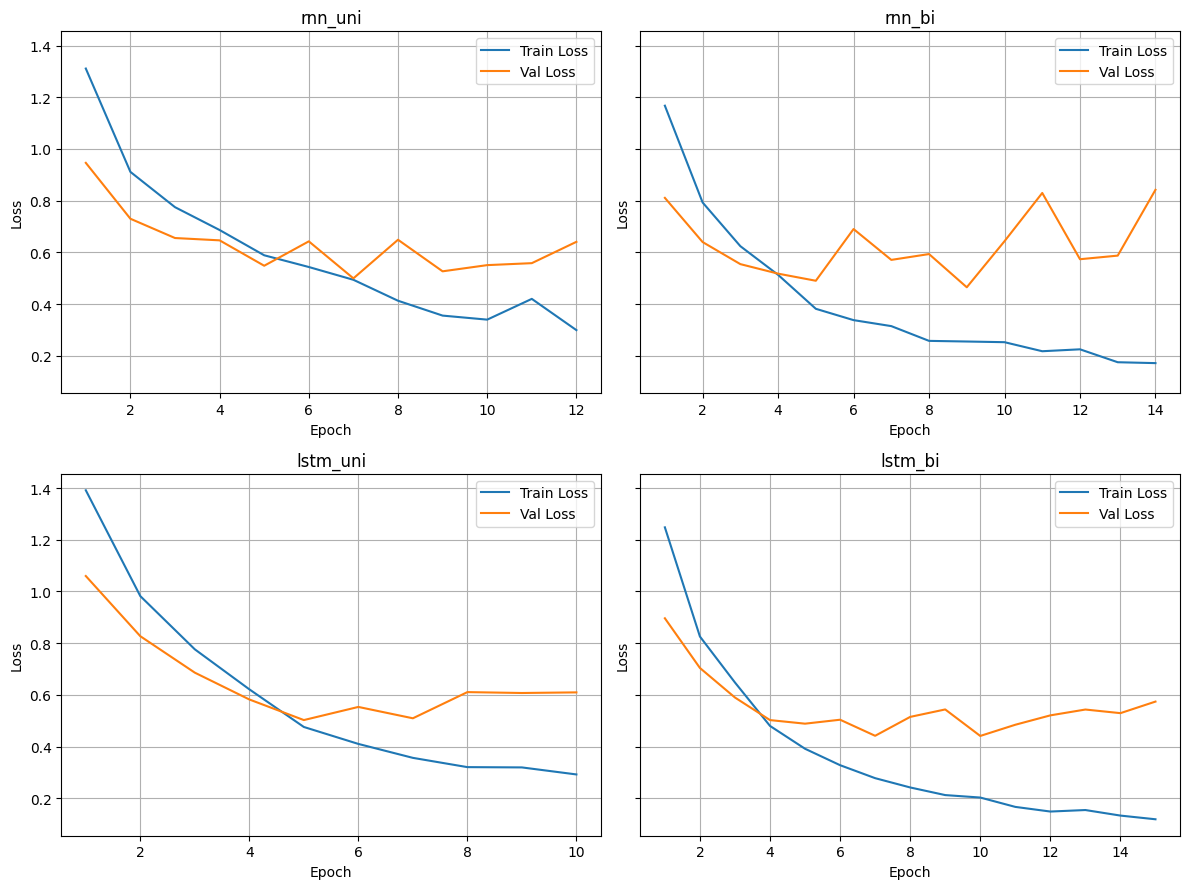

In [ ]:
### YOUR CODE STARTS HERE ###

# 1. Display stage1_results_df comparing performance across all 4 trained recurrent models
display(stage1_results_df)

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()  # Flatten to easily iterate over the 4 axes

# 3 & 4. Plot Training Loss and Validation Loss vs Epoch, and add formatting
for idx, (name, history_df) in enumerate(stage1_histories.items()):
    ax = axes[idx]

    # Plot Train and Val Loss
    ax.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss')

    # Add title, labels, legend, and grid
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

# 5. Apply tight layout and show the plots
plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

### 5.6 Test Evaluation & Confusion Matrix for the Best Model (Q23) [2 Marks]

Q23: Evaluate the winning Stage-1 model on the test set and display its confusion matrix.

**Function `plot_confusion_matrix(targets, predictions, title)`:**
1. Build a `NUM_CLASSES × NUM_CLASSES` count matrix from `(targets, predictions)` pairs.
2. Plot with `plt.imshow()` using `cmap='Blues'`, annotating each cell with its count and row-normalized percentage.
3. Label axes with `CLASSES`, add colorbar and title.
4. Return a per-class DataFrame with support and recall.

**Then:**
1. Identify `best_stage1_name` from `stage1_results_df` (row 0, already sorted by val accuracy).
2. Store its config as `best_stage1_config` (looked up in `STAGE1_CORE_CONFIGS`) and its checkpoint path as `best_stage1_checkpoint` (in `MODEL_DIR`). Q27 reuses both under these names.
3. Rebuild `RecurrentHead(**config)`, load the checkpoint `state_dict` via `torch.load()`, move to `DEVICE`.
4. Evaluate on `stage1_test_loader` using `evaluate_classification_model()`, storing the results as `test_loss_s1, test_acc_s1, test_preds_s1, test_targets_s1` — **Q30 reuses `test_acc_s1` and `test_loss_s1`**.
5. Print Test metrics (accuracy, loss, macro/weighted precision via `sklearn.metrics.precision_score`) and display the confusion matrix.


Test Accuracy: 0.8079
Test Loss: 0.4929
Macro Precision: 0.8131
Weighted Precision: 0.8130


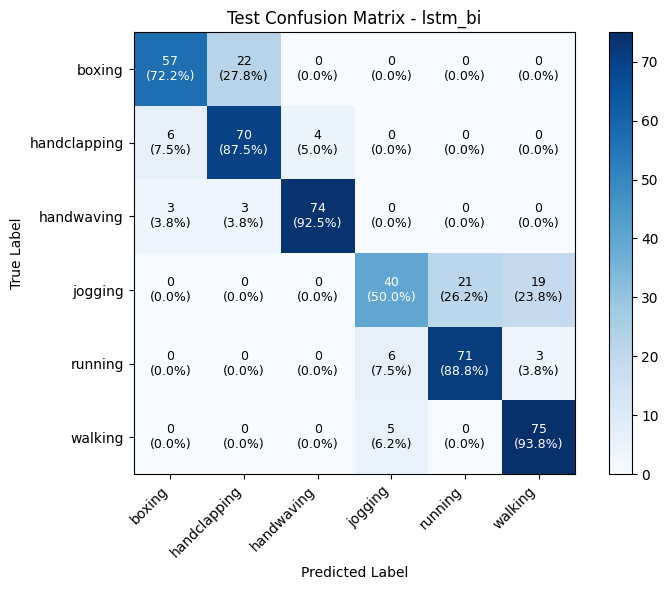

,Class,Support,Recall
0,boxing,79,0.721519
1,handclapping,80,0.875000
2,handwaving,80,0.925000
3,jogging,80,0.500000
4,running,80,0.887500
5,walking,80,0.937500


In [ ]:
### YOUR CODE STARTS HERE ###

def plot_confusion_matrix(targets, predictions, title):
    # 1. Build a NUM_CLASSES x NUM_CLASSES count matrix from (targets, predictions) pairs
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for t, p in zip(targets, predictions):
        cm[t, p] += 1

    # Calculate row-normalized percentages
    row_sums = cm.sum(axis=1, keepdims=True)
    # Avoid division by zero
    row_sums_safe = np.where(row_sums == 0, 1, row_sums)
    cm_perc = (cm / row_sums_safe) * 100

    # 2 & 3. Plot it with imshow, annotating each cell, label axes, add colorbar and title
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(CLASSES)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    # Annotate cells
    threshold = cm.max() / 2.
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            text = f"{cm[i, j]}\n({cm_perc[i, j]:.1f}%)"
            ax.text(j, i, text, ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black",
                    fontsize=9)

    plt.tight_layout()
    plt.show()

    # 4. Return a per-class DataFrame with support and recall
    support = cm.sum(axis=1)
    recall = np.diag(cm) / row_sums_safe.flatten()
    df_metrics = pd.DataFrame({
        'Class': CLASSES,
        'Support': support,
        'Recall': recall
    })
    return df_metrics

# 1. Identify best_stage1_name from stage1_results_df (row 0, already sorted by val accuracy)
best_stage1_name = stage1_results_df.iloc[0]['model_name']

# 2. Store best_stage1_config (from STAGE1_CORE_CONFIGS) and best_stage1_checkpoint
#    (in MODEL_DIR) - Q27 reuses both under these names
best_stage1_config = STAGE1_CORE_CONFIGS[best_stage1_name]
best_stage1_checkpoint = MODEL_DIR / f"stage1_{best_stage1_name}_best_acc.pt"

# 3. Rebuild RecurrentHead(**config), load the checkpoint state_dict, move it to DEVICE
best_model_s1 = RecurrentHead(**best_stage1_config)
best_model_s1.load_state_dict(torch.load(best_stage1_checkpoint, map_location=DEVICE))
best_model_s1.to(DEVICE)

# 4. Evaluate on stage1_test_loader using evaluate_classification_model (loss, accuracy, predictions, targets)
test_loss_s1, test_acc_s1, test_preds_s1, test_targets_s1 = evaluate_classification_model(
    best_model_s1, stage1_test_loader
)

# 5. Print Test metrics (accuracy, macro/weighted precision, loss) and display the confusion matrix
from sklearn.metrics import precision_score

macro_precision = precision_score(test_targets_s1, test_preds_s1, average='macro', zero_division=0)
weighted_precision = precision_score(test_targets_s1, test_preds_s1, average='weighted', zero_division=0)

print(f"Test Accuracy: {test_acc_s1:.4f}")
print(f"Test Loss: {test_loss_s1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")

df_class_metrics = plot_confusion_matrix(
    test_targets_s1,
    test_preds_s1,
    title=f"Test Confusion Matrix - {best_stage1_name}"
)
display(df_class_metrics)

### YOUR CODE ENDS HERE ###

## Task 6: Stage-2 End-to-End CNN Fine-Tuning & Model Comparison [20 Marks]


### 6.1 Custom CNN Backbone - `CustomCNN` (Q24) [3 Marks]

Q24: Define a custom 4-block CNN backbone `CustomCNN` trained from scratch.

**Architecture** (applied per-frame, output reshaped to `(B, T, 512)`):

| Block | Layers | Output channels |
|---|---|---|
| 1 | `Conv2d(3, 64, k=3, p=1)` → `BatchNorm2d(64)` → `ReLU` → `MaxPool2d(2)` | 64 |
| 2 | `Conv2d(64, 128, k=3, p=1)` → `BatchNorm2d(128)` → `ReLU` → `MaxPool2d(2)` | 128 |
| 3 | `Conv2d(128, 256, k=3, p=1)` → `BatchNorm2d(256)` → `ReLU` → `MaxPool2d(2)` | 256 |
| 4 | `Conv2d(256, 512, k=3, p=1)` → `BatchNorm2d(512)` → `ReLU` (no pool) | 512 |

Followed by `AdaptiveAvgPool2d((1, 1))` and `Linear(512, output_dim)` projection.

- `set_trainable(mode='full')`: Always marks every parameter trainable (CustomCNN is trained from scratch).
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → conv blocks → pool → flatten → projection → reshape to `(B, T, output_dim)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class CustomCNN(nn.Module):
    """
    Small CNN trained from scratch: 4 Conv-BatchNorm-ReLU(-MaxPool) blocks,
    global average pool, and a linear projection to FEATURE_DIM.
    """
    def __init__(self, output_dim=FEATURE_DIM):
        super().__init__()
        self.output_dim = output_dim

        # Build 4 conv blocks as described in the architecture table
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # self.projection = nn.Linear(512, output_dim)
        self.projection = nn.Linear(512, output_dim)

    def set_trainable(self, mode="full"):
        # CustomCNN is trained from scratch; all parameters are always trainable.
        # Mark every parameter trainable (requires_grad = True)
        for param in self.parameters():
            param.requires_grad = True

    def forward(self, clip):
        # Flatten (B, T, C, H, W) -> (B*T, C, H, W), conv blocks,
        # pool + flatten + projection, reshape to (B, T, output_dim)
        B, T, C, H, W = clip.shape
        x = clip.view(B * T, C, H, W)

        # Convolutional blocks
        x = self.features(x)

        # Global average pool
        x = self.pool(x)

        # Flatten
        x = x.view(B * T, -1)

        # Linear projection
        x = self.projection(x)

        # Reshape back to (B, T, output_dim)
        x = x.view(B, T, self.output_dim)

        return x

### YOUR CODE ENDS HERE ###

### 6.2 Pretrained ResNet-18 Backbone - `ResNetCNN` (Q25) [4 Marks]

Q25: Define a pretrained ResNet-18 backbone with selective residual-block unfreezing.

- `__init__()`: Load `models.resnet18(weights=ResNet18_Weights.DEFAULT)`, replace `fc` with `nn.Identity()`. Store `output_dim = FEATURE_DIM` (512).
- `set_trainable(mode)`: First freeze ALL backbone parameters. Then based on `mode`:
  - `'block4'`: unfreeze residual block 4 (`backbone.layer4`) only
  - `'block3_4'`: unfreeze residual blocks 3 and 4 (`backbone.layer3` and `backbone.layer4`)
  - `'full'`: unfreeze the entire backbone
- `forward(clip)`: Flatten `(B, T, C, H, W)` → `(B*T, C, H, W)` → `self.backbone` → reshape to `(B, T, output_dim)`.


In [ ]:
### YOUR CODE STARTS HERE ###

class ResNetCNN(nn.Module):
    """
    ImageNet ResNet-18 with selectable trainable depth:
    'block4', 'block3_4', or 'full'.
    """
    def __init__(self):
        super().__init__()
        # Load models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Replace backbone.fc with nn.Identity()
        self.backbone.fc = nn.Identity()

        # Set self.output_dim = FEATURE_DIM
        self.output_dim = FEATURE_DIM

    def set_trainable(self, mode):
        # 1. Freeze every backbone parameter first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 2. Based on mode ('block4' / 'block3_4' / 'full'), selectively unfreeze
        if mode == 'block4':
            for param in self.backbone.layer4.parameters():
                param.requires_grad = True
        elif mode == 'block3_4':
            for param in self.backbone.layer3.parameters():
                param.requires_grad = True
            for param in self.backbone.layer4.parameters():
                param.requires_grad = True
        elif mode == 'full':
            for param in self.backbone.parameters():
                param.requires_grad = True
        else:
            raise ValueError(f"Unknown mode: {mode}")

    def forward(self, clip):
        # Flatten (B, T, C, H, W) -> (B*T, C, H, W), backbone, reshape to (B, T, output_dim)
        B, T, C, H, W = clip.shape
        x = clip.view(B * T, C, H, W)
        features = self.backbone(x)
        return features.view(B, T, self.output_dim)

### YOUR CODE ENDS HERE ###

### 6.3 Combined End-to-End Model - `Stage2Model` (Q26) [3 Marks]

Q26: Combine a CNN backbone with `RecurrentHead` into an end-to-end fine-tunable model.

- `__init__(self, cnn, head)`: Store `cnn` and `head` as submodules.
- `train(self, mode=True)`: Call `super().train(mode)`. If entering train mode, force any `BatchNorm` module whose parameters are **all frozen** back into `eval()` so running stats don't update.
- `forward(self, clip)`: `self.cnn(clip)` → `self.head(features)` → return logits.

**Verification:** Build `Stage2Model` with `ResNetCNN` for each mode (`'block4'`, `'block3_4'`, `'full'`) and display trainable vs frozen parameter breakdowns using `get_submodule_parameter_breakdown()`.


In [ ]:
### YOUR CODE STARTS HERE ###

class Stage2Model(nn.Module):
    """CNN front-end + transferred RecurrentHead, fine-tuned end-to-end."""

    def __init__(self, cnn, head):
        super().__init__()
        # Store cnn and head as attributes
        self.cnn = cnn
        self.head = head

    def train(self, mode=True):
        # Call super().train(mode); if entering train mode, force frozen BatchNorm
        # modules back into eval() so their running stats don't update
        super().train(mode)
        if mode:
            for module in self.modules():
                if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                    # Check if all parameters in this BatchNorm are frozen
                    if not any(p.requires_grad for p in module.parameters()):
                        module.eval()

    def forward(self, clip):
        # Run clip through self.cnn, then self.head, return logits
        features = self.cnn(clip)
        logits = self.head(features)
        return logits

# Sanity-check: build Stage2Model with ResNetCNN for each of
# 'block4' / 'block3_4' / 'full', display trainable-vs-frozen parameter breakdown
print("Sanity-checking Stage2Model with ResNetCNN trainable modes...")

for mode in ['block4', 'block3_4', 'full']:
    print(f"\n--- Stage2Model with ResNetCNN ({mode}) ---")
    cnn = ResNetCNN()
    cnn.set_trainable(mode)

    # Instantiate a default head for the sanity check
    head = RecurrentHead(**STAGE1_CORE_CONFIGS["rnn_uni"])

    stage2_model = Stage2Model(cnn, head)

    breakdown_df = get_submodule_parameter_breakdown(stage2_model)
    display(breakdown_df)

### YOUR CODE ENDS HERE ###

Sanity-checking Stage2Model with ResNetCNN trainable modes...

--- Stage2Model with ResNetCNN (block4) ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,cnn,ResNetCNN,"11,176,512","8,393,728","2,782,784"
1,head,RecurrentHead,"37,382","37,382",0
2,Total,Stage2Model,"11,213,894","8,431,110","2,782,784"



--- Stage2Model with ResNetCNN (block3_4) ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,cnn,ResNetCNN,"11,176,512","10,493,440","683,072"
1,head,RecurrentHead,"37,382","37,382",0
2,Total,Stage2Model,"11,213,894","10,530,822","683,072"



--- Stage2Model with ResNetCNN (full) ---


,Submodule,Type,Total Parameters,Trainable,Frozen
0,cnn,ResNetCNN,"11,176,512","11,176,512",0
1,head,RecurrentHead,"37,382","37,382",0
2,Total,Stage2Model,"11,213,894","11,213,894",0


### 6.4 Fine-Tuning with Pretrained Weights (Q27) [4 Marks]

Q27: Warm-start Stage-2 models from the winning Stage-1 head weights and fine-tune end-to-end.

**Implement `build_stage2_model(cnn_kind, cnn_mode, head_state_dict, head_config=None)`:**
1. Build `CustomCNN()` or `ResNetCNN()` based on `cnn_kind`.
2. Instantiate a fresh `RecurrentHead` matching the winning Stage-1 config (`head_config` or `best_stage1_config`).
3. Load pretrained head weights: `head.load_state_dict(head_state_dict)` - keep the head **trainable** (not frozen) so it adapts alongside the CNN.
4. Wrap in `Stage2Model(cnn, head)` and call `cnn.set_trainable(cnn_mode)`.
5. Return the assembled `Stage2Model`.

**4 Stage-2 configurations (`STAGE2_CONFIGS`):**

| Name | `cnn_kind` | `cnn_mode` |
|---|---|---|
| `custom_cnn` | `'custom'` | `'full'` |
| `resnet18_block4` | `'resnet'` | `'block4'` |
| `resnet18_block3_4` | `'resnet'` | `'block3_4'` |
| `resnet18_full` | `'resnet'` | `'full'` |

**Training hyperparameters:**
- `max_epochs = STAGE2_MAX_EPOCHS` (50)
- `learning_rate = STAGE2_LR` (1e-4)
- `batch_size = STAGE2_BATCH_SIZE` (4)
- `accumulation_steps = STAGE2_GRAD_ACCUMULATION` (4) → effective batch size = 16
- `patience = 5`

For each configuration, call `set_seed(SEED)` **before building the model**, then train using `train_classification_model()`, save best checkpoints as `stage2_{name}_best_acc.pt`, store histories in `stage2_histories`, and compile/display `stage2_results_df` sorted by `best_val_accuracy` (descending).

**Required `stage2_results_df` columns** - later questions index these by name, so use them exactly:
`model_name`, `trainable_cnn_part`, `hidden_dim`, `total_params_m`, `trainable_params_m`, `best_val_accuracy`, `best_val_accuracy_epoch`, `best_val_loss`, `best_val_loss_epoch`, `epochs_run`, `minutes`

**Required `stage2_histories` shape:** a dict keyed by model name, each value the `history_df` returned by `train_classification_model()`.

In [ ]:
### YOUR CODE STARTS HERE ###

def build_stage2_model(cnn_kind, cnn_mode, head_state_dict, head_config=None):
    # 1. Build CustomCNN() or ResNetCNN() based on cnn_kind.
    if cnn_kind == 'custom':
        cnn = CustomCNN()
    elif cnn_kind == 'resnet':
        cnn = ResNetCNN()
    else:
        raise ValueError(f"Unknown cnn_kind: {cnn_kind}")

    # 2. Instantiate a fresh RecurrentHead matching the winning Stage-1 config
    if head_config is None:
        head_config = best_stage1_config

    head = RecurrentHead(**head_config)

    # 3. Load pretrained head weights - keep the head trainable (not frozen)
    head.load_state_dict(head_state_dict)
    for param in head.parameters():
        param.requires_grad = True

    # 4. Wrap in Stage2Model(cnn, head) and call cnn.set_trainable(cnn_mode).
    model = Stage2Model(cnn, head)
    model.cnn.set_trainable(cnn_mode)

    # 5. Return the assembled Stage2Model.
    return model

# 4 Stage-2 configurations
STAGE2_CONFIGS = {
    "custom_cnn": {"cnn_kind": "custom", "cnn_mode": "full"},
    "resnet18_block4": {"cnn_kind": "resnet", "cnn_mode": "block4"},
    "resnet18_block3_4": {"cnn_kind": "resnet", "cnn_mode": "block3_4"},
    "resnet18_full": {"cnn_kind": "resnet", "cnn_mode": "full"},
}

stage2_histories = {}
stage2_results = []

# Load the winning Stage-1 head weights
head_state_dict = torch.load(best_stage1_checkpoint, map_location=DEVICE)

print("Starting Stage-2 End-to-End Fine-Tuning...")

for name, config in STAGE2_CONFIGS.items():
    print(f"\n--- Training Stage-2 Model: {name} ---")

    # Call set_seed(SEED) before building the model
    set_seed(SEED)

    # Build model and move to DEVICE
    model = build_stage2_model(
        cnn_kind=config['cnn_kind'],
        cnn_mode=config['cnn_mode'],
        head_state_dict=head_state_dict,
        head_config=best_stage1_config
    ).to(DEVICE)

    checkpoint_path = MODEL_DIR / f"stage2_{name}_best_acc.pt"

    # Train the model
    history_df, summary_dict = train_classification_model(
        model=model,
        train_loader=stage2_train_loader,
        val_loader=stage2_val_loader,
        max_epochs=STAGE2_MAX_EPOCHS,
        learning_rate=STAGE2_LR,
        checkpoint_path=checkpoint_path,
        model_name=name,
        accumulation_steps=STAGE2_GRAD_ACCUMULATION,
        patience=5
    )

    # Store history
    stage2_histories[name] = history_df

    # Append results for the summary table
    stage2_results.append({
        'model_name': name,
        'trainable_cnn_part': config['cnn_mode'],
        'hidden_dim': HIDDEN_SIZE,
        'total_params_m': summary_dict['total_parameters'] / 1e6,
        'trainable_params_m': summary_dict['trainable_parameters'] / 1e6,
        'best_val_accuracy': summary_dict['best_val_accuracy'],
        'best_val_accuracy_epoch': summary_dict['best_val_accuracy_epoch'],
        'best_val_loss': summary_dict['best_val_loss'],
        'best_val_loss_epoch': summary_dict['best_val_loss_epoch'],
        'epochs_run': summary_dict['epochs_run'],
        'minutes': summary_dict['seconds'] / 60.0
    })

# Compile all model summaries into stage2_results_df
stage2_results_df = pd.DataFrame(stage2_results)

# Sort the DataFrame by Validation Accuracy descending
stage2_results_df = stage2_results_df.sort_values(by='best_val_accuracy', ascending=False).reset_index(drop=True)

# Display it
display(stage2_results_df)

### YOUR CODE ENDS HERE ###

Starting Stage-2 End-to-End Fine-Tuning...

--- Training Stage-2 Model: custom_cnn ---
[custom_cnn] Epoch 001/050 | Train Loss: 1.4220 Acc: 0.3429 | Val Loss: 1.2138 Acc: 0.3854
[custom_cnn] Epoch 010/050 | Train Loss: 0.9504 Acc: 0.5308 | Val Loss: 0.9558 Acc: 0.5651
[custom_cnn] Early stopping triggered at epoch 14

--- Training Stage-2 Model: resnet18_block4 ---
[resnet18_block4] Epoch 001/050 | Train Loss: 0.4988 Acc: 0.8017 | Val Loss: 0.3051 Acc: 0.8776
[resnet18_block4] Epoch 010/050 | Train Loss: 0.0188 Acc: 0.9967 | Val Loss: 0.2117 Acc: 0.9349
[resnet18_block4] Early stopping triggered at epoch 13

--- Training Stage-2 Model: resnet18_block3_4 ---
[resnet18_block3_4] Epoch 001/050 | Train Loss: 0.5330 Acc: 0.7912 | Val Loss: 0.2126 Acc: 0.9167
[resnet18_block3_4] Epoch 010/050 | Train Loss: 0.0275 Acc: 0.9915 | Val Loss: 0.1221 Acc: 0.9661
[resnet18_block3_4] Early stopping triggered at epoch 14

--- Training Stage-2 Model: resnet18_full ---
[resnet18_full] Epoch 001/050 | Tr

,model_name,trainable_cnn_part,hidden_dim,total_params_m,trainable_params_m,best_val_accuracy,best_val_accuracy_epoch,best_val_loss,best_val_loss_epoch,epochs_run,minutes
0,resnet18_block3_4,block3_4,64,11.473222,10.790150,0.979167,8,0.090935,9,14,23.379518
1,resnet18_block4,block4,64,11.473222,8.690438,0.971354,8,0.109456,8,13,20.934479
2,resnet18_full,full,64,11.473222,11.473222,0.971354,6,0.095382,6,11,25.417837
3,custom_cnn,full,64,2.112262,2.112262,0.604167,13,0.894731,9,14,46.911227


### 6.5 Stage-2 Results & Learning Curves (Q28) [2 Marks]

Q28: Display the Stage-2 results table for all fine-tuned models and plot loss convergence curves.

**Steps:**
1. Display `stage2_results_df` comparing all 4 fine-tuned Stage-2 models.
2. Create a `2×2` subplot grid (`figsize=(12, 9)`, `sharey=True`).
3. For each of the 4 Stage-2 models, plot **Training Loss** and **Validation Loss** vs Epoch.
4. Add subplot titles, axis labels, legends, and grid. `plt.tight_layout()` and `plt.show()`.


,model_name,trainable_cnn_part,hidden_dim,total_params_m,trainable_params_m,best_val_accuracy,best_val_accuracy_epoch,best_val_loss,best_val_loss_epoch,epochs_run,minutes
0,resnet18_block3_4,block3_4,64,11.473222,10.790150,0.979167,8,0.090935,9,14,23.379518
1,resnet18_block4,block4,64,11.473222,8.690438,0.971354,8,0.109456,8,13,20.934479
2,resnet18_full,full,64,11.473222,11.473222,0.971354,6,0.095382,6,11,25.417837
3,custom_cnn,full,64,2.112262,2.112262,0.604167,13,0.894731,9,14,46.911227


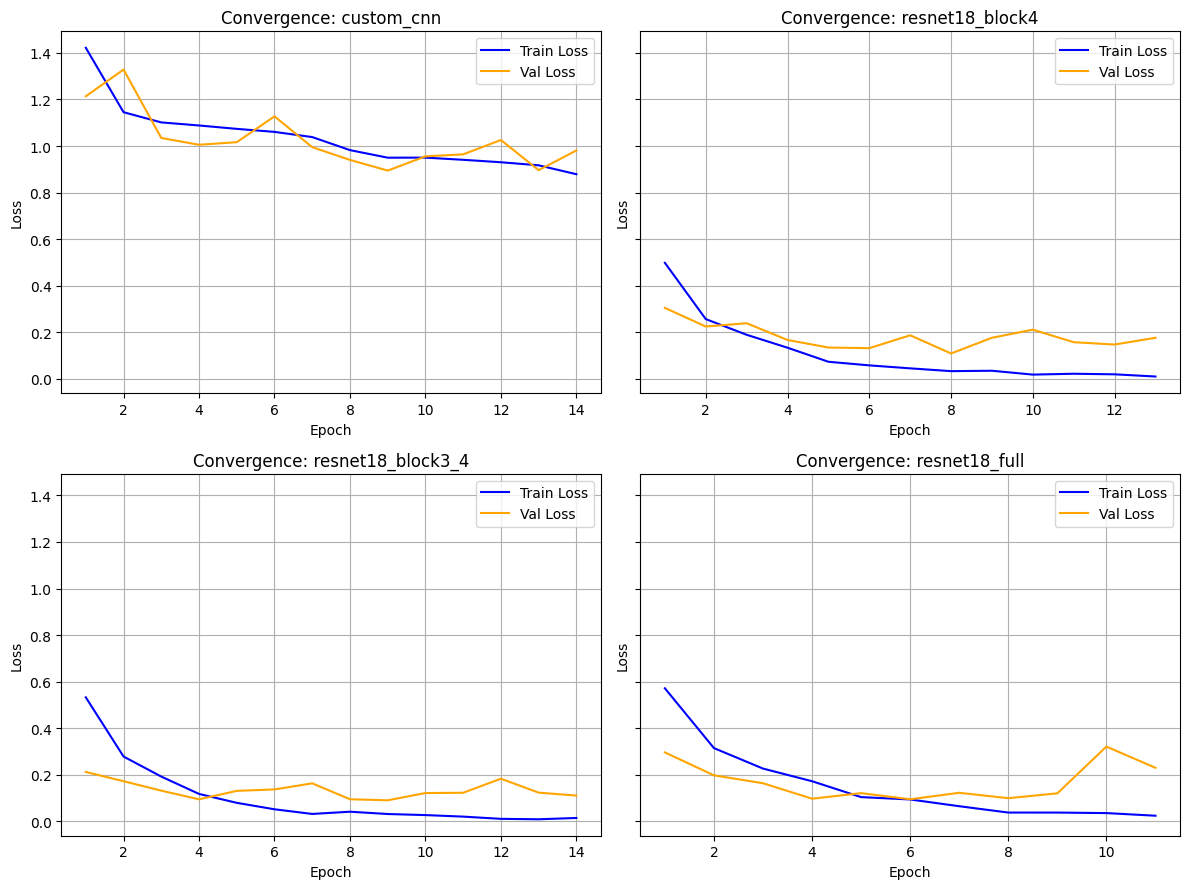

In [ ]:
### YOUR CODE STARTS HERE ###

# 1. Display stage2_results_df comparing all 4 fine-tuned Stage-2 models.
display(stage2_results_df)

# 2. Create a 2x2 subplot grid (figsize=(12, 9), sharey=True).
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

# 3 & 4. Plot Training Loss and Validation Loss vs Epoch, and add formatting
for idx, (name, history_df) in enumerate(stage2_histories.items()):
    ax = axes[idx]

    # Plot Train and Val Loss
    ax.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='blue')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='orange')

    # Add title, labels, legend, and grid
    ax.set_title(f"Convergence: {name}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

# 5. Apply tight layout and show the plots
plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE ###

### 6.6 Test Evaluation & Confusion Matrix for the Best Model (Q29) [2 Marks]

Q29: Evaluate the best Stage-2 model on the held-out test set and display its confusion matrix.

**Steps:**
1. Identify `best_stage2_name` from `stage2_results_df` (row 0, already sorted by val accuracy).
2. Look up its `(cnn_kind, cnn_mode)` in `STAGE2_CONFIGS` and its checkpoint path in `MODEL_DIR`.
3. Rebuild the model via `build_stage2_model(...)`, load checkpoint `state_dict` via `torch.load()`, move to `DEVICE`.
4. Evaluate on `stage2_test_loader` using `evaluate_classification_model()`, storing the results as `test_loss_s2, test_acc_s2, test_preds_s2, test_targets_s2` — **Q30 reuses `test_acc_s2` and `test_loss_s2`**.
5. Print Test metrics (accuracy, loss, macro/weighted precision).
6. Display the `6×6` test confusion matrix via `plot_confusion_matrix()`.
7. Free memory: `del model` + `gc.collect()` + `torch.cuda.empty_cache()`.


Test Accuracy: 0.9436
Test Loss: 0.2058
Macro Precision: 0.9459
Weighted Precision: 0.9457


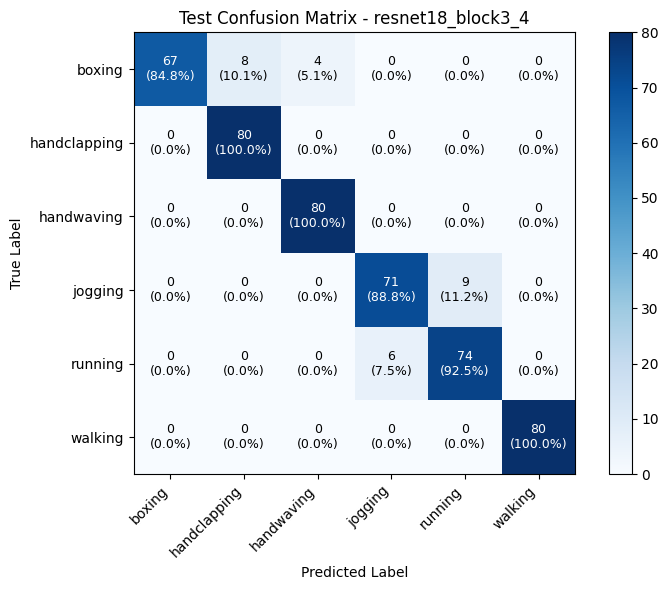

,Class,Support,Recall
0,boxing,79,0.848101
1,handclapping,80,1.000000
2,handwaving,80,1.000000
3,jogging,80,0.887500
4,running,80,0.925000
5,walking,80,1.000000


In [ ]:
### YOUR CODE STARTS HERE ###

# 1. Identify best_stage2_name from stage2_results_df (row 0, already sorted by val accuracy)
best_stage2_name = stage2_results_df.iloc[0]['model_name']

# 2. Look up its (cnn_kind, cnn_mode) in STAGE2_CONFIGS and its checkpoint path in MODEL_DIR
cnn_kind = STAGE2_CONFIGS[best_stage2_name]['cnn_kind']
cnn_mode = STAGE2_CONFIGS[best_stage2_name]['cnn_mode']
best_stage2_checkpoint = MODEL_DIR / f"stage2_{best_stage2_name}_best_acc.pt"

# 3. Rebuild model via build_stage2_model(...), load checkpoint state_dict, move to DEVICE
winning_s2_model = build_stage2_model(
    cnn_kind=cnn_kind,
    cnn_mode=cnn_mode,
    head_state_dict=head_state_dict,
    head_config=best_stage1_config
)
winning_s2_model.load_state_dict(torch.load(best_stage2_checkpoint, map_location=DEVICE))
winning_s2_model.to(DEVICE)

# 4. Evaluate on stage2_test_loader using evaluate_classification_model() - get loss, accuracy, predictions, targets
test_loss_s2, test_acc_s2, test_preds_s2, test_targets_s2 = evaluate_classification_model(
    winning_s2_model,
    stage2_test_loader
)

# 5. Print Test metrics (accuracy, loss, macro/weighted precision)
from sklearn.metrics import precision_score

macro_prec_s2 = precision_score(test_targets_s2, test_preds_s2, average='macro', zero_division=0)
weighted_prec_s2 = precision_score(test_targets_s2, test_preds_s2, average='weighted', zero_division=0)

print(f"Test Accuracy: {test_acc_s2:.4f}")
print(f"Test Loss: {test_loss_s2:.4f}")
print(f"Macro Precision: {macro_prec_s2:.4f}")
print(f"Weighted Precision: {weighted_prec_s2:.4f}")

# 6. Display 6x6 test confusion matrix via plot_confusion_matrix()
class_metrics_s2 = plot_confusion_matrix(
    test_targets_s2,
    test_preds_s2,
    title=f"Test Confusion Matrix - {best_stage2_name}"
)
display(class_metrics_s2)

# 7. Free GPU memory (del winning_s2_model, gc.collect(), torch.cuda.empty_cache())
del winning_s2_model
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

### YOUR CODE ENDS HERE ###

### 6.7 Final Summary Table & Model Comparison (Q30) [2 Marks]

Q30: Create a final summary table comparing Stage-1 winner vs Stage-2 winner.

**Steps:**
1. Build a `pd.DataFrame` with 2 rows (Stage-1 winner, Stage-2 winner) and columns:
   - `Stage`, `Model Name`, `Selection Criterion` (validation accuracy), `Validation Accuracy`, `Test Accuracy`, `Test Loss`
2. Display the summary table.
3. Compute test accuracy improvement in percentage points:
   ```python
   improvement = (test_acc_s2 - test_acc_s1) * 100
   ```
4. Print a one-line conclusion stating whether fine-tuning the CNN improved or hurt test accuracy, and by how many percentage points.


In [ ]:
### YOUR CODE STARTS HERE ###

# 1. Build a pd.DataFrame with 2 rows (Stage-1 winner, Stage-2 winner) and columns:
#          ['Stage', 'Model Name', 'Selection Criterion', 'Validation Accuracy', 'Test Accuracy', 'Test Loss']
final_summary_df = pd.DataFrame([
    {
        'Stage': 'Stage-1',
        'Model Name': best_stage1_name,
        'Selection Criterion': 'Validation Accuracy',
        'Validation Accuracy': stage1_results_df.iloc[0]['best_val_accuracy'],
        'Test Accuracy': test_acc_s1,
        'Test Loss': test_loss_s1
    },
    {
        'Stage': 'Stage-2',
        'Model Name': best_stage2_name,
        'Selection Criterion': 'Validation Accuracy',
        'Validation Accuracy': stage2_results_df.iloc[0]['best_val_accuracy'],
        'Test Accuracy': test_acc_s2,
        'Test Loss': test_loss_s2
    }
], columns=['Stage', 'Model Name', 'Selection Criterion', 'Validation Accuracy', 'Test Accuracy', 'Test Loss'])

# 2. Display the summary table
display(final_summary_df)

# 3. Compute improvement = (test_acc_s2 - test_acc_s1) * 100 and print conclusion
improvement = (test_acc_s2 - test_acc_s1) * 100
effect = "improved" if improvement > 0 else "hurt"
print(f"Conclusion: Fine-tuning the CNN {effect} test accuracy by {abs(improvement):.2f} percentage points.")

### YOUR CODE ENDS HERE ###

,Stage,Model Name,Selection Criterion,Validation Accuracy,Test Accuracy,Test Loss
0,Stage-1,lstm_bi,Validation Accuracy,0.833333,0.807933,0.492883
1,Stage-2,resnet18_block3_4,Validation Accuracy,0.979167,0.943633,0.205774


Conclusion: Fine-tuning the CNN improved test accuracy by 13.57 percentage points.
